# Overview (Candidate)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import heart_utilities as u
import heart_plot as plot

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# # adjust pandas display options to max
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# # adjust pandas display options to ensure full display of content
# pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    3.0.2
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_parquet("../Data/CAN_Heart_Data.parquet")
# display
df.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Weight_kg_Registrsation_CAN,Height_cm_Registration_CAN,BMI_Listing_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,...,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,0,DILATED MYOPATHY: IDIOPATHIC,M,A,65.771,173.0,22.0470,US Citizen,CA,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2013,329.0,No,2,2,1,5,Identical
1,0,DILATED MYOPATHY: OTHER SPECIFY,M,O,72.575,185.0,21.1093,US Citizen,TX,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,2592.0,Yes,1,2,2,5,Identical
2,0,DILATED MYOPATHY: ISCHEMIC,M,O,106.000,175.0,34.5096,US Citizen,NY,ATTENDED COLLEGE/TECHNICAL SCHOOL,...,Orthotopic Bicaval,2013,2012,2913.0,Yes,0,1,2,3,Identical
3,0,DILATED MYOPATHY: ISCHEMIC,M,A,111.000,178.0,35.0335,US Citizen,NY,HIGH SCHOOL (9-12) or GED,...,Orthotopic Bicaval,2013,2012,1225.0,Yes,2,2,2,6,Identical
4,0,DILATED MYOPATHY: IDIOPATHIC,M,A,72.000,172.0,24.3375,US Citizen,NC,ASSOCIATE/BACHELOR DEGREE,...,Orthotopic Bicaval,2013,2012,2785.0,Yes,0,2,2,4,Identical


In [3]:
df.info(max_cols=df.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 30300 entries, 0 to 30299
Data columns (total 144 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  30300 non-null  category
 1    WaitListDiagnosisCode_CAN                     30300 non-null  category
 2    Gender_CAN                                    30300 non-null  category
 3    BloodGroup_CAN                                30300 non-null  category
 4    Weight_kg_Registrsation_CAN                   30250 non-null  float64 
 5    Height_cm_Registration_CAN                    30187 non-null  float64 
 6    BMI_Listing_CAN                               30185 non-null  float64 
 7    Citizenship_CAN                               30300 non-null  category
 8    ResidencyStateRegistration_CAN                30300 non-null  category
 9    EducationLevel_CAN                            30

## Gender

In [4]:
# nans
u.any_nans(df)

╭────────────────────────────── Total Rows: 30,300 ───────────────────────────────╮
│  ⚠ Missing Values Found                                                         │
│  ───────────────────────────────────────────────────────                        │
│     Column                                     Null Count        Percentage     │
│     HemodynamicsRegistration_PCW_CAN                2,838           9.3663%     │
│     HemodynamicsTransplant_PCW_CAN                  2,226           7.3465%     │
│     HemodynamicsRegistration_CO_CAN                 1,730           5.7096%     │
│     HemodynamicsRegistration_PA_MN_CAN              1,390           4.5875%     │
│     FunctionalStatusTransplant_CAN                  1,375           4.5380%     │
│     HemodynamicsTransplant_CO_CAN                   1,371           4.5248%     │
│     HemodynamicsTransplant_PA_MN_CAN                1,184           3.9076%     │
│     HemodynamicsRegistration_PA_DIA_CAN             1,072           3.5380%     │
│     HemodynamicsRegistration_SYS_CAN                1,050           3.4653%     │
│     FunctionalStatusRegistration_CAN                  975           3.2178%     │
│     HemodynamicsTransplant_PA_DIA_CAN                 885           2.9208%     │
│     HemodynamicsTransplant_SYS_CAN                    861           2.8416%     │
│     TotalBilirubinTransplant_CAN                      118           0.3894%     │
│     BMI_Listing_CAN                                   115           0.3795%     │
│     Height_cm_Registration_CAN                        113           0.3729%     │
│     CreatinineRegistration_CAN                        104           0.3432%     │
│     CreatinineTransplant_CAN                           55           0.1815%     │
│     Weight_kg_Registrsation_CAN                        50           0.1650%     │
│     BMI_Listing_CALC_CAN                               43           0.1419%     │
│     Weight_kg_Listing_CAN                              22           0.0726%     │
│     BMI_Removal_CAN                                    13           0.0429%     │
│     BMI_Calc_CAN                                       13           0.0429%     │
│     Weight_kg_Removal_CAN                               7           0.0231%     │
│     Weight_kg_CAN                                       7           0.0231%     │
│     Height_cm_Listing_CAN                               1           0.0033%     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [5]:
df.Gender_CAN.value_counts(dropna=False)

Gender_CAN
M    22236
F     8064
Name: count, dtype: int64

In [6]:
df_m = df[df.Gender_CAN == 'M'].copy()
df_f = df[df.Gender_CAN == 'F'].copy()
#
df_m.shape, df_f.shape

((22236, 144), (8064, 144))

### User Function(s)

In [7]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()



def apply_pca_feature_engineering(data, features, prefix, n_components=0.9, seed=SEED):
    """
    Standardizes features, performs PCA, and appends scores and variance weights.
    
    Args:
        data: Input DataFrame.
        features: List of numeric column names to reduce.
        prefix: String prefix for new columns (e.g., 'hemo_reg').
        n_components: Variance threshold or fixed number of components.
        seed: Random state for reproducibility.
    """
    if not features:
        return data

    # Scale and Transform
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(data[features])
    
    pca = PCA(n_components=n_components, random_state=seed)
    pca_scores = pca.fit_transform(x_scaled)
    
    # Extract Variance Stats
    exp_var = pca.explained_variance_ratio_
    # Weights normalized to the sum of explained variance
    # pc_weights = exp_var / np.sum(exp_var)
    n_pcs = pca.n_components_

    # Create Column Names
    pc_cols = [f'PC{i+1}_{prefix}' for i in range(n_pcs)]
    var_cols = [f'PC{i+1}_{prefix}_var' for i in range(n_pcs)]

    # Build DataFrames for concatenation (Vectorized)
    pca_df = pd.DataFrame(pca_scores, columns=pc_cols, index=data.index)
    
    # Using np.tile is the fastest way to broadcast weights across the index
    var_data = np.tile(exp_var, (len(data), 1))
    # var_data = np.tile(pc_weights, (len(data), 1))
    var_df = pd.DataFrame(var_data, columns=var_cols, index=data.index)

    # Clean and Merge
    # adding new engineered columns in one pass
    df_out = pd.concat([
        data,
        # data.drop(columns=features), # Dropping original features and 
        pca_df, 
        var_df
    ], axis=1)

    print(f"[{prefix}] Retained {n_pcs} components ({exp_var.sum():.2%} variance explained)")
    
    return df_out

## Hemodynamics

### Hemodynamics Registration

#### Male

In [8]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsRegistration', cat=False)
# feature
total_features = features

✦ Feature Profiler │ Match: 'HemodynamicsRegistration' │ Found: 5                                  
╭─────────────────────────────────────┬─────────┬───────┬───────┬──────┬──────┬──────┬──────┬─────╮
│ Feature                             │ Missing │  Mean │   Std │  Min │  25% │  50% │  75% │ Max │
├─────────────────────────────────────┼─────────┼───────┼───────┼──────┼──────┼──────┼──────┼─────┤
│ HemodynamicsRegistration_CO_CAN     │    1250 │  4.42 │  1.35 │ 0.39 │ 3.50 │ 4.30 │ 5.20 │  15 │
│ HemodynamicsRegistration_PA_DIA_CAN │     731 │ 20.93 │  8.78 │    0 │   15 │   20 │   27 │  83 │
│ HemodynamicsRegistration_PA_MN_CAN  │     998 │ 29.17 │ 10.32 │    0 │   21 │   29 │   36 │  87 │
│ HemodynamicsRegistration_PCW_CAN    │    2087 │ 19.63 │  8.89 │    0 │   13 │   20 │   26 │  50 │
│ HemodynamicsRegistration_SYS_CAN    │     713 │ 42.79 │ 14.47 │    0 │   32 │   42 │   53 │ 123 │
╰─────────────────────────────────────┴─────────┴───────┴───────┴──────┴──────┴──────┴──────┴─────╯

Those hemodynamic variables (Cardiac Output, Pulmonary Artery pressures, and Wedge pressure) are notorious for having missing data in donor registries because they require invasive Swan-Ganz catheterization, which isn't performed on every donor.

* CO (Cardiac Output)
* PA_DIA (Pulmonary Artery Diastolic)
* PA_MN (Pulmonary Artery Mean)
* PCW (Pulmonary Capillary Wedge)
* SYS (Systemic Arterial Systolic)

In [9]:
df_m[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.237766,-0.216207,-0.261080,-0.177958
HemodynamicsRegistration_PA_DIA_CAN,-0.237766,1.000000,0.895253,0.822036,0.783360
HemodynamicsRegistration_PA_MN_CAN,-0.216207,0.895253,1.000000,0.838893,0.919842
HemodynamicsRegistration_PCW_CAN,-0.261080,0.822036,0.838893,1.000000,0.763254
HemodynamicsRegistration_SYS_CAN,-0.177958,0.783360,0.919842,0.763254,1.000000


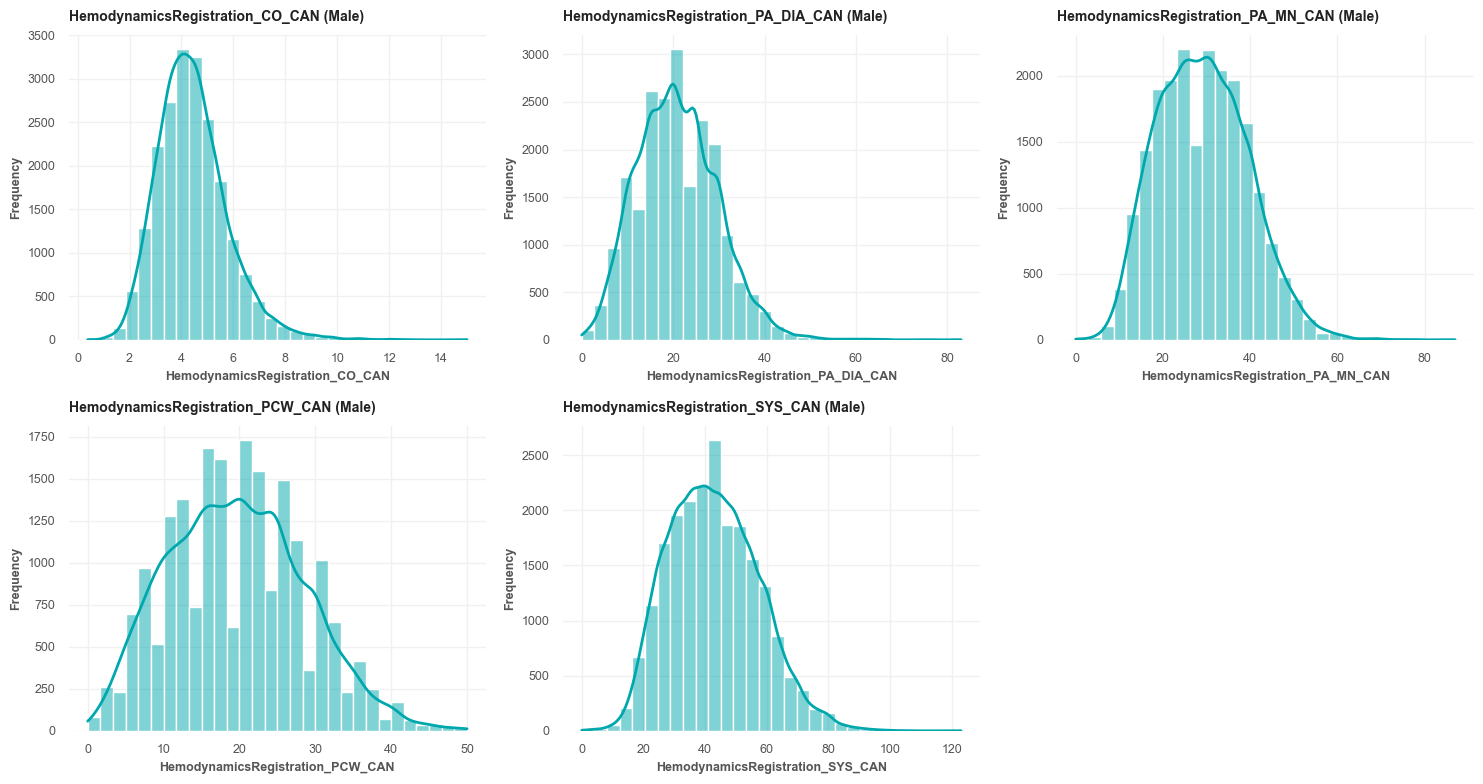

In [10]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [11]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_CO_CAN ─────────────────╮
│                                                                                  │
│  Cohort Overview (Male)                                                          │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing          Unknown=1,250                1,403.1d              │
│    Known / Complete            Known=20,986                1,438.8d              │
│  Difference:            -35.7 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.3166                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0308 (Negligible)                                     │
│  95% CI:                [-0.0879, 0.0262]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [12]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

╭─ HemodynamicsRegistration_CO_CAN ──────────────╮
│                                                │
│  Predictive Metrics Summary (Male)             │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     -0.002    7.43e-01    0.001%    │
│    Spearman    +0.000    9.94e-01    0.000%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### Median Imputation

In [13]:
# Median impute
df_m['HemodynamicsRegistration_CO_CAN'] = df_m['HemodynamicsRegistration_CO_CAN'].fillna(
    df_m['HemodynamicsRegistration_CO_CAN'].median()
)

In [14]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PA_DIA_CAN ───────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=731                1,325.6d                                    │
│    Known / Complete            Known=21,505                1,440.5d                                    │
│  Difference:            -114.9 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0133                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.0993 (Negligible)                                                           │
│  95% CI:                [-0.1731, -0.0256]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [15]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_PA_DIA_IsMissing'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_PA_DIA_CAN'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [16]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

╭─ HemodynamicsRegistration_PA_DIA_CAN ────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.037    4.33e-08    0.135%                              │
│    Spearman    +0.033    1.07e-06    0.107%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

In [17]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PA_MN_CAN ──────────────╮
│                                                                                  │
│  Cohort Overview (Male)                                                          │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=998                1,481.3d              │
│    Known / Complete            Known=21,238                1,434.7d              │
│  Difference:            +46.6 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.2519                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0403 (Negligible)                                      │
│  95% CI:                [-0.0232, 0.1038]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [18]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

╭─ HemodynamicsRegistration_PA_MN_CAN ─────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.046    2.06e-11    0.211%                              │
│    Spearman    +0.041    2.32e-09    0.168%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [19]:
# Median impute
df_m['HemodynamicsRegistration_PA_MN_CAN'] = df_m['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [20]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PCW_CAN ────────────────╮
│                                                                                  │
│  Cohort Overview (Male)                                                          │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing          Unknown=2,087                1,442.3d              │
│    Known / Complete            Known=20,149                1,436.2d              │
│  Difference:            +6.1 days                                                │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.8223                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0053 (Negligible)                                      │
│  95% CI:                [-0.0398, 0.0504]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [21]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

╭─ HemodynamicsRegistration_PCW_CAN ───────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.049    5.44e-12    0.236%                              │
│    Spearman    +0.044    4.37e-10    0.193%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [22]:
# Median impute
df_m['HemodynamicsRegistration_PCW_CAN'] = df_m['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_m['HemodynamicsRegistration_PCW_CAN'].median()
)

In [23]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_SYS_CAN ──────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=713                1,321.7d                                    │
│    Known / Complete            Known=21,523                1,440.6d                                    │
│  Difference:            -118.9 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0114                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.1028 (Negligible)                                                           │
│  95% CI:                [-0.1774, -0.0281]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [24]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

╭─ HemodynamicsRegistration_SYS_CAN ───────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.046    2.13e-11    0.208%                              │
│    Spearman    +0.042    6.45e-10    0.177%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [25]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_SYS_IsMissing'] = df_m['HemodynamicsRegistration_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_SYS_CAN'] = df_m['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_m['HemodynamicsRegistration_SYS_CAN'].median()
)

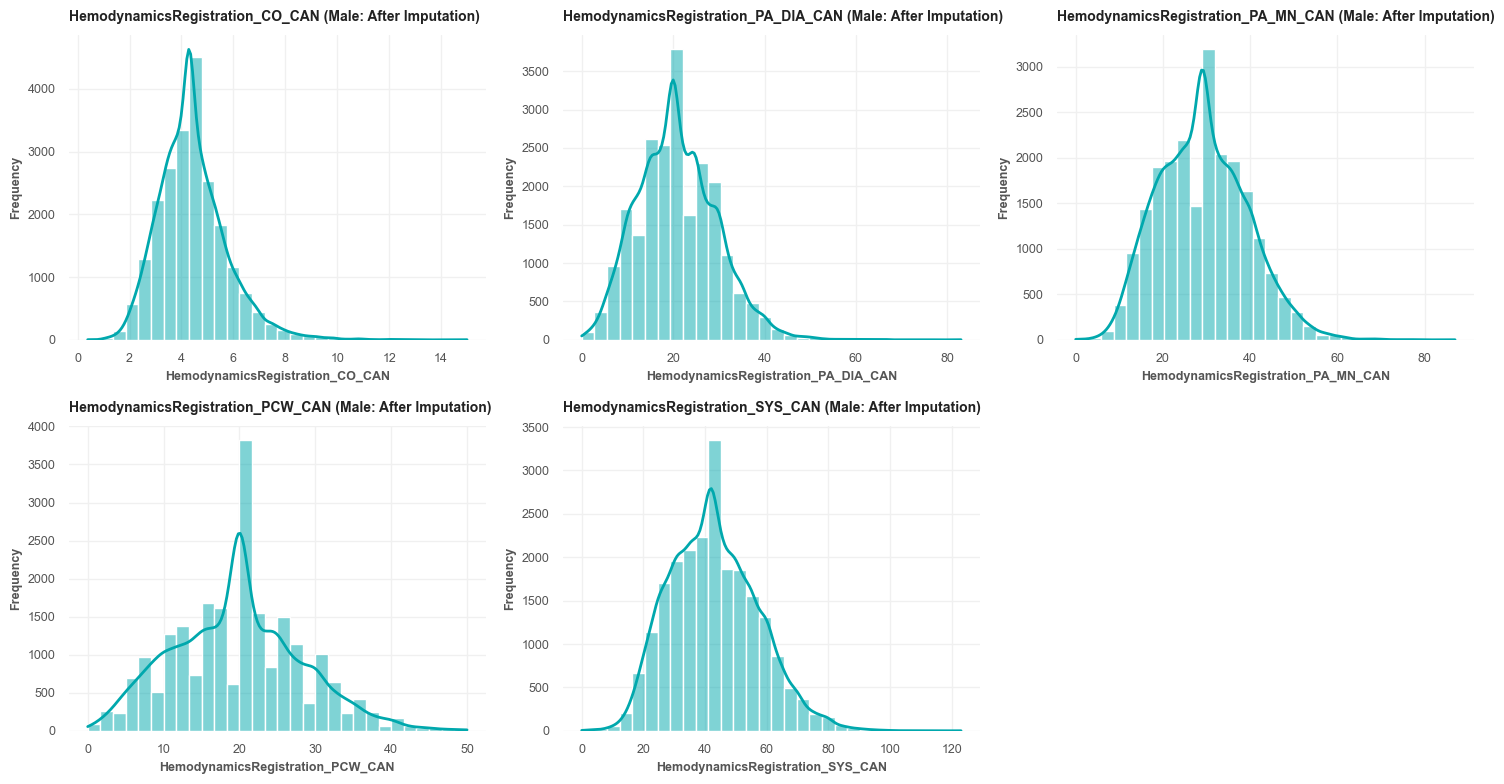

In [26]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male: After Imputation)')

#### Female

In [27]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsRegistration', cat=False)

✦ Feature Profiler │ Match: 'HemodynamicsRegistration' │ Found: 5                                   
╭─────────────────────────────────────┬─────────┬───────┬───────┬──────┬───────┬──────┬──────┬─────╮
│ Feature                             │ Missing │  Mean │   Std │  Min │   25% │  50% │  75% │ Max │
├─────────────────────────────────────┼─────────┼───────┼───────┼──────┼───────┼──────┼──────┼─────┤
│ HemodynamicsRegistration_CO_CAN     │     480 │  3.82 │  1.23 │ 0.91 │  2.97 │ 3.68 │ 4.50 │  15 │
│ HemodynamicsRegistration_PA_DIA_CAN │     341 │ 19.80 │  8.38 │    0 │    14 │   19 │   25 │  91 │
│ HemodynamicsRegistration_PA_MN_CAN  │     392 │ 27.74 │  9.85 │    4 │ 20.92 │   27 │   34 │  96 │
│ HemodynamicsRegistration_PCW_CAN    │     751 │ 18.21 │  8.42 │    0 │    12 │   18 │   24 │  50 │
│ HemodynamicsRegistration_SYS_CAN    │     337 │ 40.68 │ 13.58 │    0 │    31 │   40 │   50 │ 130 │
╰─────────────────────────────────────┴─────────┴───────┴───────┴──────┴───────┴──────┴──────┴─────╯

In [28]:
df_f[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.204048,-0.177482,-0.235581,-0.129799
HemodynamicsRegistration_PA_DIA_CAN,-0.204048,1.000000,0.884069,0.820830,0.789169
HemodynamicsRegistration_PA_MN_CAN,-0.177482,0.884069,1.000000,0.826852,0.909595
HemodynamicsRegistration_PCW_CAN,-0.235581,0.820830,0.826852,1.000000,0.751176
HemodynamicsRegistration_SYS_CAN,-0.129799,0.789169,0.909595,0.751176,1.000000


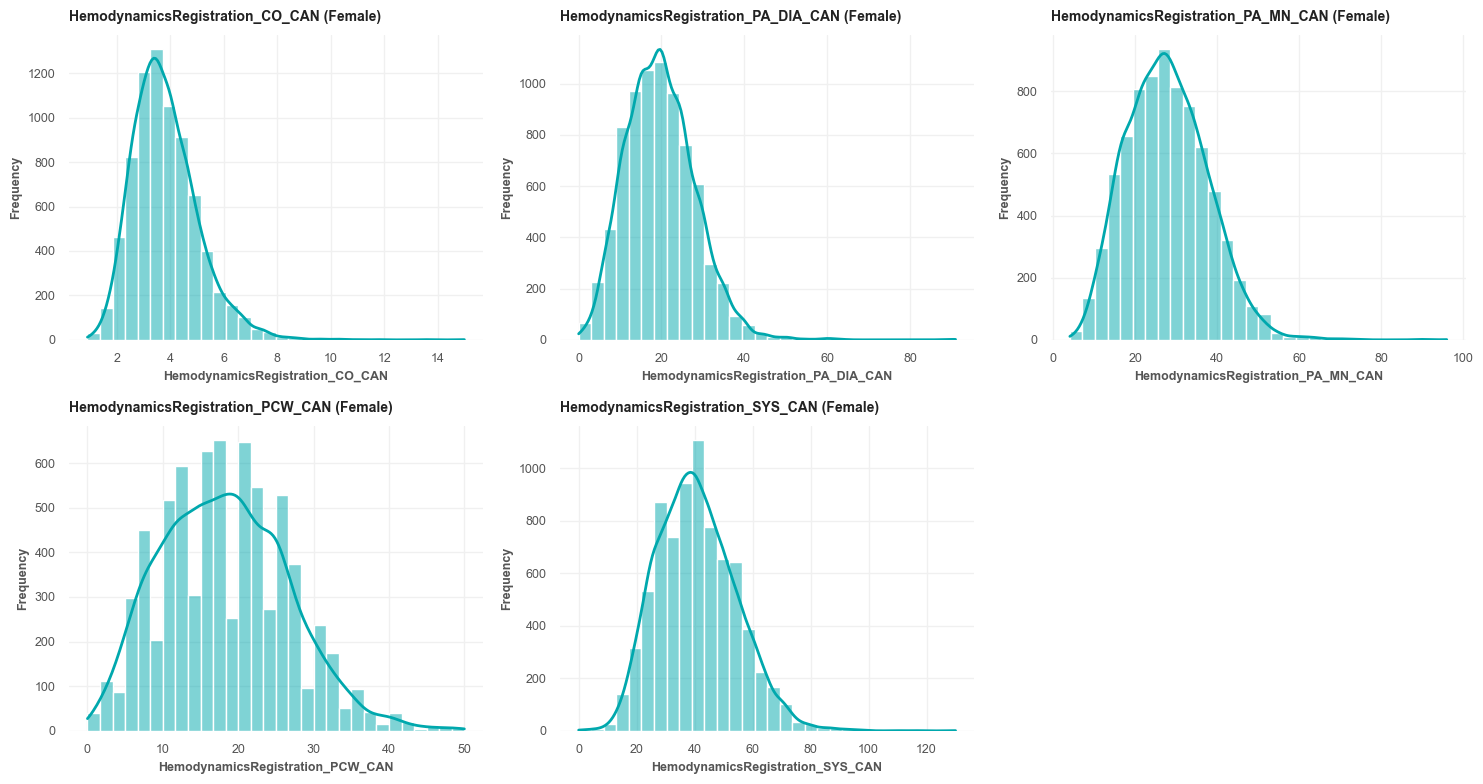

In [29]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [30]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_CO_CAN ─────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=480                1,490.4d              │
│    Known / Complete             Known=7,584                1,420.0d              │
│  Difference:            +70.4 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.2262                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0611 (Negligible)                                      │
│  95% CI:                [-0.0312, 0.1533]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [31]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

╭─ HemodynamicsRegistration_CO_CAN ────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.025    3.23e-02    0.060%                              │
│    Spearman    -0.024    3.92e-02    0.056%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [32]:
# Median impute
df_f['HemodynamicsRegistration_CO_CAN'] = df_f['HemodynamicsRegistration_CO_CAN'].fillna(
    df_f['HemodynamicsRegistration_CO_CAN'].median()
)

In [33]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PA_DIA_CAN ─────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=341                1,428.5d              │
│    Known / Complete             Known=7,723                1,424.0d              │
│  Difference:            +4.4 days                                                │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.9485                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0039 (Negligible)                                      │
│  95% CI:                [-0.1046, 0.1123]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [34]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

╭─ HemodynamicsRegistration_PA_DIA_CAN ────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.046    4.65e-05    0.215%                              │
│    Spearman    +0.045    8.55e-05    0.200%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [35]:
# Median impute
df_f['HemodynamicsRegistration_PA_DIA_CAN'] = df_f['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [36]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_MN_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PA_MN_CAN ────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Female)                                                                              │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=392                1,566.9d                                    │
│    Known / Complete             Known=7,672                1,416.9d                                    │
│  Difference:            +150.0 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0245                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             0.1301 (Negligible)                                                            │
│  95% CI:                [0.0286, 0.2316]                                                               │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [37]:
# Median impute
df_f['HemodynamicsRegistration_PA_MN_CAN'] = df_f['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [38]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PCW_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_PCW_CAN ────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=751                1,455.1d              │
│    Known / Complete             Known=7,313                1,421.0d              │
│  Difference:            +34.1 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.4569                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0295 (Negligible)                                      │
│  95% CI:                [-0.0456, 0.1046]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [39]:
# Median impute
df_f['HemodynamicsRegistration_PCW_CAN'] = df_f['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_f['HemodynamicsRegistration_PCW_CAN'].median()
)

In [40]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_SYS_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsRegistration_SYS_CAN ────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=337                1,417.4d              │
│    Known / Complete             Known=7,727                1,424.5d              │
│  Difference:            -7.1 days                                                │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.9179                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0062 (Negligible)                                     │
│  95% CI:                [-0.1152, 0.1029]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [41]:
# Median impute
df_f['HemodynamicsRegistration_SYS_CAN'] = df_f['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_f['HemodynamicsRegistration_SYS_CAN'].median()
)

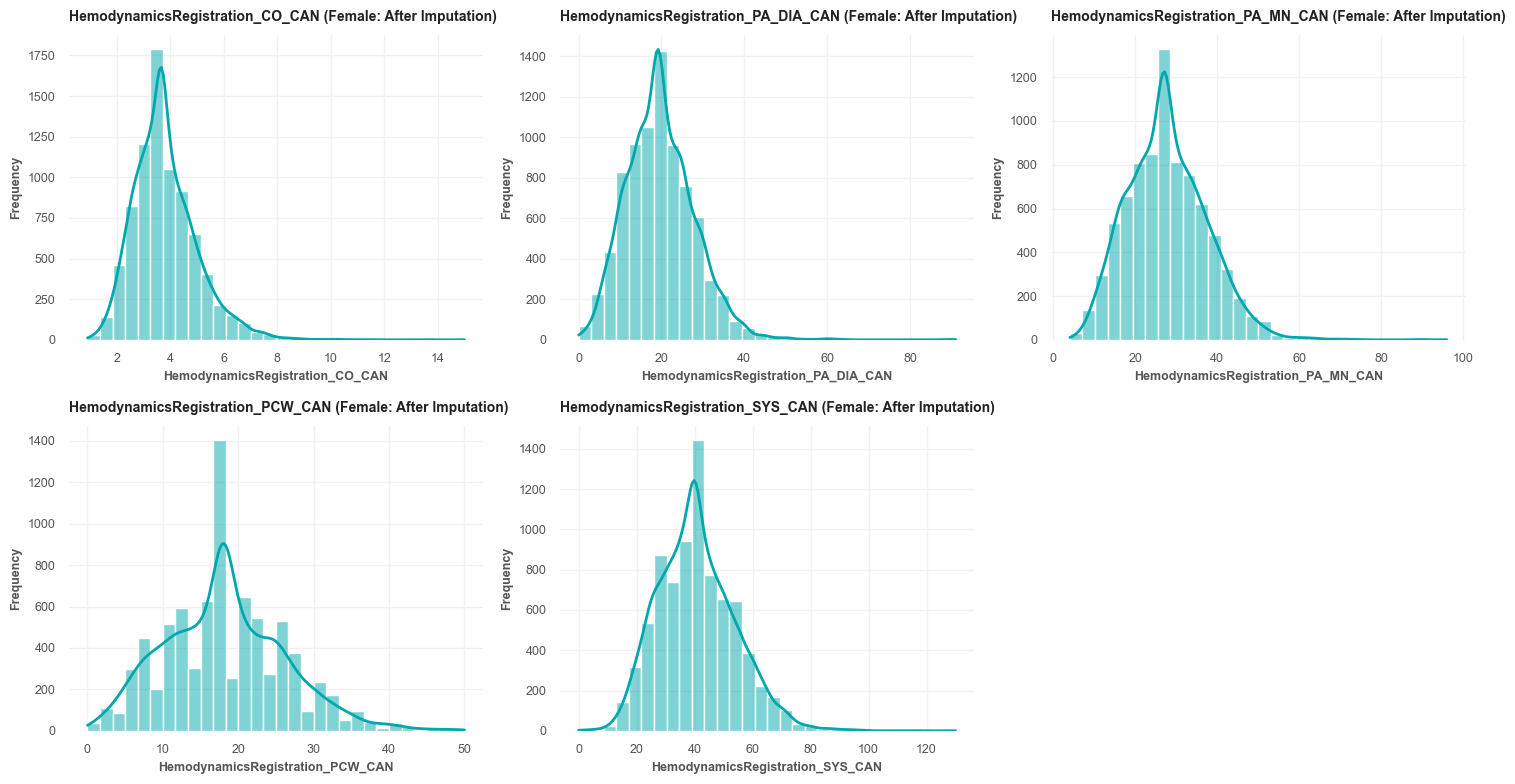

In [42]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female: After Imputation)')

### Hemodynamics Transplant

#### Male

In [43]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsTransplant', cat=False)
# add
total_features.extend(features)

✦ Feature Profiler │ Match: 'HemodynamicsTransplant' │ Found: 5                                  
╭───────────────────────────────────┬─────────┬───────┬───────┬──────┬──────┬──────┬──────┬─────╮
│ Feature                           │ Missing │  Mean │   Std │  Min │  25% │  50% │  75% │ Max │
├───────────────────────────────────┼─────────┼───────┼───────┼──────┼──────┼──────┼──────┼─────┤
│ HemodynamicsTransplant_CO_CAN     │     974 │  4.71 │  1.46 │ 0.20 │ 3.70 │ 4.54 │ 5.50 │  15 │
│ HemodynamicsTransplant_PA_DIA_CAN │     603 │ 19.41 │  8.58 │    0 │   13 │   18 │   25 │ 110 │
│ HemodynamicsTransplant_PA_MN_CAN  │     837 │ 27.34 │ 10.05 │    0 │   20 │   26 │   34 │ 110 │
│ HemodynamicsTransplant_PCW_CAN    │    1614 │ 18.15 │  8.81 │    0 │   11 │   17 │   24 │  50 │
│ HemodynamicsTransplant_SYS_CAN    │     585 │ 40.26 │ 14.06 │    1 │   30 │   39 │   50 │ 159 │
╰───────────────────────────────────┴─────────┴───────┴───────┴──────┴──────┴──────┴──────┴─────╯

In [44]:
df_m[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.242740,-0.213030,-0.245328,-0.182213
HemodynamicsTransplant_PA_DIA_CAN,-0.242740,1.000000,0.904281,0.823678,0.794816
HemodynamicsTransplant_PA_MN_CAN,-0.213030,0.904281,1.000000,0.836996,0.918459
HemodynamicsTransplant_PCW_CAN,-0.245328,0.823678,0.836996,1.000000,0.767413
HemodynamicsTransplant_SYS_CAN,-0.182213,0.794816,0.918459,0.767413,1.000000


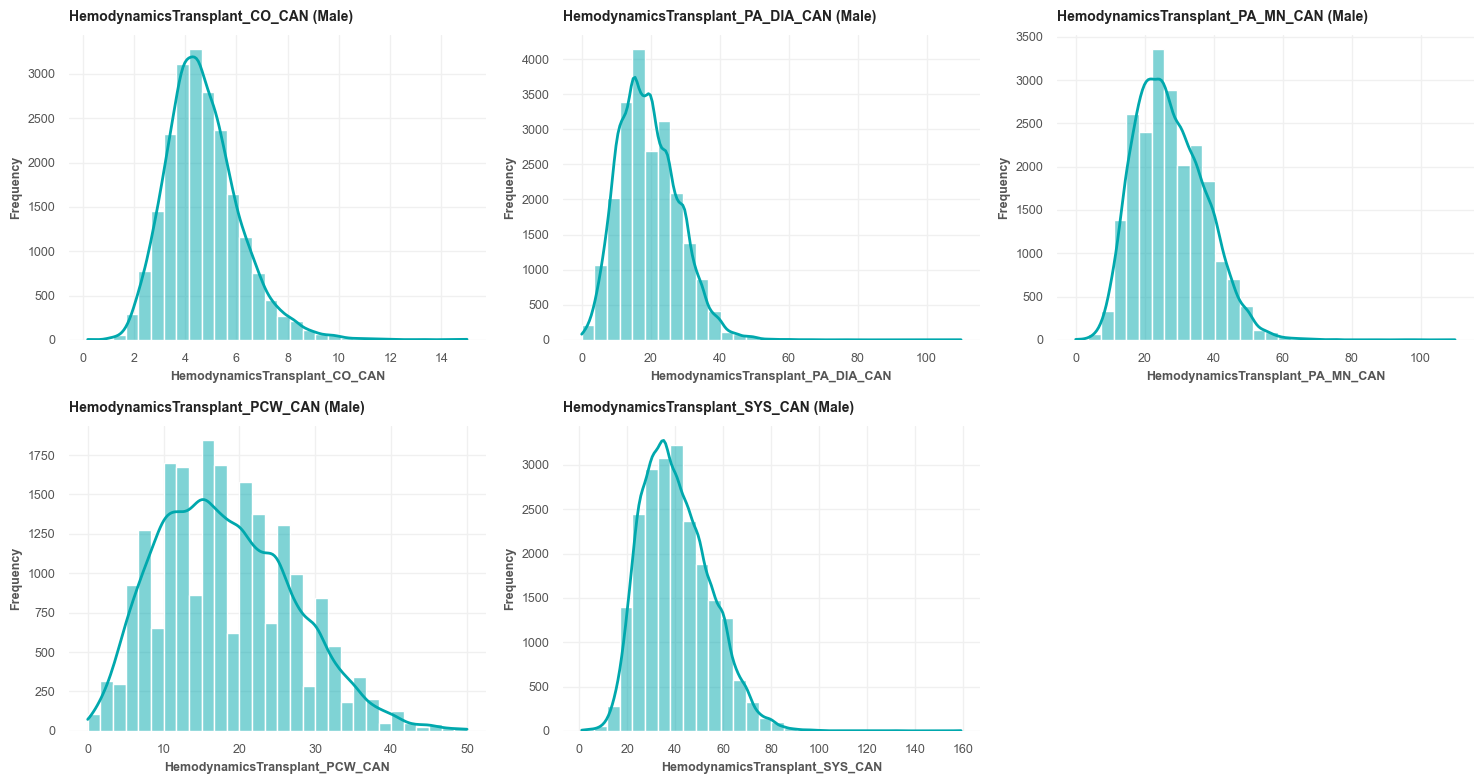

In [45]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [46]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_CO_CAN ─────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=974                1,282.7d                                    │
│    Known / Complete            Known=21,262                1,443.8d                                    │
│  Difference:            -161.1 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0001                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.1393 (Negligible)                                                           │
│  95% CI:                [-0.2035, -0.0750]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [47]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

╭─ HemodynamicsTransplant_CO_CAN ──────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.007    3.15e-01    0.005%                              │
│    Spearman    +0.020    3.90e-03    0.039%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [48]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_CO_IsMissing'] = df_m['HemodynamicsTransplant_CO_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_CO_CAN'] = df_m['HemodynamicsTransplant_CO_CAN'].fillna(
    df_m['HemodynamicsTransplant_CO_CAN'].median()
)

In [49]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PA_DIA_CAN ─────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=603                1,194.8d                                    │
│    Known / Complete            Known=21,633                1,443.5d                                    │
│  Difference:            -248.7 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.2151 (Small)                                                                │
│  95% CI:                [-0.2960, -0.1341]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [50]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

╭─ HemodynamicsTransplant_PA_DIA_CAN ──────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.008    2.39e-01    0.006%                              │
│    Spearman    -0.014    3.80e-02    0.020%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [51]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_DIA_IsMissing'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_DIA_CAN'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [52]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PA_MN_CAN ──────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=837                1,317.1d                                    │
│    Known / Complete            Known=21,399                1,441.4d                                    │
│  Difference:            -124.3 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0049                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.1075 (Negligible)                                                           │
│  95% CI:                [-0.1765, -0.0384]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [53]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

╭─ HemodynamicsTransplant_PA_MN_CAN ─────────────╮
│                                                │
│  Predictive Metrics Summary (Male)             │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     +0.005    4.22e-01    0.003%    │
│    Spearman    -0.003    6.42e-01    0.001%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [54]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_MN_IsMissing'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_MN_CAN'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [55]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PCW_CAN ────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing          Unknown=1,614                1,276.3d                                    │
│    Known / Complete            Known=20,622                1,449.3d                                    │
│  Difference:            -173.0 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.1496 (Negligible)                                                           │
│  95% CI:                [-0.2003, -0.0990]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [56]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

╭─ HemodynamicsTransplant_PCW_CAN ───────────────╮
│                                                │
│  Predictive Metrics Summary (Male)             │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     +0.013    5.32e-02    0.018%    │
│    Spearman    +0.003    6.93e-01    0.001%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [57]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PCW_IsMissing'] = df_m['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PCW_CAN'] = df_m['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_m['HemodynamicsTransplant_PCW_CAN'].median()
)

In [58]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_SYS_CAN ────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=585                1,175.3d                                    │
│    Known / Complete            Known=21,651                1,443.8d                                    │
│  Difference:            -268.6 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.2323 (Small)                                                                │
│  95% CI:                [-0.3144, -0.1501]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [59]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

╭─ HemodynamicsTransplant_SYS_CAN ───────────────╮
│                                                │
│  Predictive Metrics Summary (Male)             │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     +0.012    8.82e-02    0.013%    │
│    Spearman    +0.000    9.92e-01    0.000%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [60]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_SYS_IsMissing'] = df_m['HemodynamicsTransplant_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_SYS_CAN'] = df_m['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_m['HemodynamicsTransplant_SYS_CAN'].median()
)

#### Female

In [61]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsTransplant', cat=False)

✦ Feature Profiler │ Match: 'HemodynamicsTransplant' │ Found: 5                                  
╭───────────────────────────────────┬─────────┬───────┬───────┬──────┬──────┬──────┬──────┬─────╮
│ Feature                           │ Missing │  Mean │   Std │  Min │  25% │  50% │  75% │ Max │
├───────────────────────────────────┼─────────┼───────┼───────┼──────┼──────┼──────┼──────┼─────┤
│ HemodynamicsTransplant_CO_CAN     │     397 │  4.05 │  1.33 │ 0.20 │ 3.12 │ 3.90 │ 4.80 │  15 │
│ HemodynamicsTransplant_PA_DIA_CAN │     282 │ 18.65 │  8.20 │    0 │   13 │   18 │   24 │  65 │
│ HemodynamicsTransplant_PA_MN_CAN  │     347 │ 26.46 │  9.65 │    0 │   19 │   26 │   33 │  88 │
│ HemodynamicsTransplant_PCW_CAN    │     612 │ 17.08 │  8.38 │    0 │   11 │   16 │   23 │  50 │
│ HemodynamicsTransplant_SYS_CAN    │     276 │ 38.86 │ 13.29 │    0 │   29 │   38 │   47 │ 127 │
╰───────────────────────────────────┴─────────┴───────┴───────┴──────┴──────┴──────┴──────┴─────╯

In [62]:
df_f[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.210790,-0.177840,-0.231536,-0.142130
HemodynamicsTransplant_PA_DIA_CAN,-0.210790,1.000000,0.890623,0.810877,0.777492
HemodynamicsTransplant_PA_MN_CAN,-0.177840,0.890623,1.000000,0.824702,0.912752
HemodynamicsTransplant_PCW_CAN,-0.231536,0.810877,0.824702,1.000000,0.746656
HemodynamicsTransplant_SYS_CAN,-0.142130,0.777492,0.912752,0.746656,1.000000


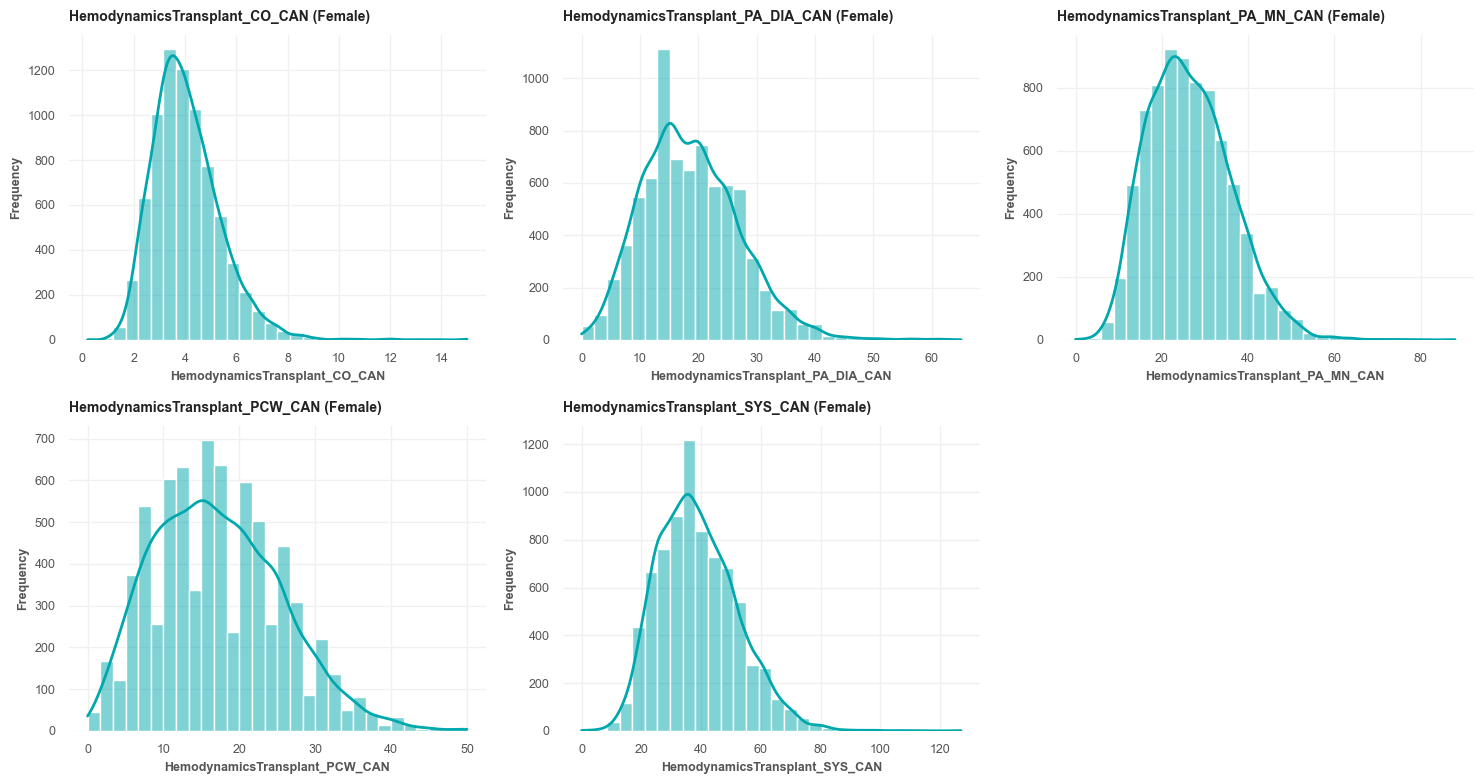

In [63]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [64]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_CO_CAN ───────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=397                1,384.8d              │
│    Known / Complete             Known=7,667                1,426.2d              │
│  Difference:            -41.5 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.5181                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0360 (Negligible)                                     │
│  95% CI:                [-0.1368, 0.0649]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [65]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

╭─ HemodynamicsTransplant_CO_CAN ──────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.023    4.26e-02    0.054%                              │
│    Spearman    -0.018    1.21e-01    0.031%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [66]:
# Median impute
df_f['HemodynamicsTransplant_CO_CAN'] = df_f['HemodynamicsTransplant_CO_CAN'].fillna(
    df_f['HemodynamicsTransplant_CO_CAN'].median()
)

In [67]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PA_DIA_CAN ───────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=282                1,385.3d              │
│    Known / Complete             Known=7,782                1,425.6d              │
│  Difference:            -40.3 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.6060                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0350 (Negligible)                                     │
│  95% CI:                [-0.1538, 0.0839]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [68]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

╭─ HemodynamicsTransplant_PA_DIA_CAN ────────────╮
│                                                │
│  Predictive Metrics Summary (Female)           │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     +0.014    2.17e-01    0.020%    │
│    Spearman    +0.002    8.64e-01    0.000%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### Median Imputation

In [69]:
# Median impute
df_f['HemodynamicsTransplant_PA_DIA_CAN'] = df_f['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [70]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PA_MN_CAN ────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=347                1,421.0d              │
│    Known / Complete             Known=7,717                1,424.3d              │
│  Difference:            -3.3 days                                                │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.9630                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0029 (Negligible)                                     │
│  95% CI:                [-0.1104, 0.1047]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [71]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

╭─ HemodynamicsTransplant_PA_MN_CAN ───────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.030    7.74e-03    0.092%                              │
│    Spearman    +0.016    1.49e-01    0.027%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [72]:
# Median impute
df_f['HemodynamicsTransplant_PA_MN_CAN'] = df_f['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [73]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_PCW_CAN ──────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=612                1,360.9d              │
│    Known / Complete             Known=7,452                1,429.4d              │
│  Difference:            -68.5 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.1840                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0594 (Negligible)                                     │
│  95% CI:                [-0.1418, 0.0230]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [74]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

╭─ HemodynamicsTransplant_PCW_CAN ───────────────╮
│                                                │
│  Predictive Metrics Summary (Female)           │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     +0.021    6.62e-02    0.045%    │
│    Spearman    +0.014    2.34e-01    0.019%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Median Imputation

In [75]:
# impute: median and use new feature for NANS
df_f['HemodynamicsTransplant_PCW_IsMissing'] = df_f['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_f['HemodynamicsTransplant_PCW_CAN'] = df_f['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_f['HemodynamicsTransplant_PCW_CAN'].median()
)

In [76]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

╭─ ⚙ Informative Missingness Log: HemodynamicsTransplant_SYS_CAN ──────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing            Unknown=276                1,376.3d              │
│    Known / Complete             Known=7,788                1,425.9d              │
│  Difference:            -49.6 days                                               │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.5305                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.0430 (Negligible)                                     │
│  95% CI:                [-0.1630, 0.0771]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [77]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

╭─ HemodynamicsTransplant_SYS_CAN ─────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     +0.032    4.88e-03    0.102%                              │
│    Spearman    +0.019    9.48e-02    0.036%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear positive directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Median Imputation

In [78]:
# Median impute
df_f['HemodynamicsTransplant_SYS_CAN'] = df_f['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_f['HemodynamicsTransplant_SYS_CAN'].median()
)

#### All features for Hemodynamics

In [79]:
# PCA - feature engineering
df_f = apply_pca_feature_engineering(df_f, total_features, "hemodynamics")
df_m = apply_pca_feature_engineering(df_m, total_features, "hemodynamics")

[hemodynamics] Retained 5 components (93.23% variance explained)
[hemodynamics] Retained 5 components (93.46% variance explained)


In [80]:
pd.set_option('display.max_columns', None)
df_f.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Weight_kg_Registrsation_CAN,Height_cm_Registration_CAN,BMI_Listing_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,LifeSupportRegistration_ECMO_CAN,LifeSupportRegistration_IABP_CAN,LifeSupportInhaled_CAN,InotropesIVRegistration_CAN,LifeSupportRegistration_PGE_CAN,LifeSupportMechanismRegistration_OTHER_CAN,VentricularDeviceTypeRegistration_CAN,VentricularDeviceBrandRegistration_CAN,FunctionalStatusRegistration_CAN,PrimaryPaymentRegistration_CAN,DiagnosisAtListing_CAN,DiabetesType_CAN,DialysisTypeRegistration_CAN,CerebroVascularDisease_CAN,PreviousMalignancy_CAN,CreatinineRegistration_CAN,DefibrillatorImplantRegistration_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_CO_CAN,InotropesVasodilatorsRegistration_SYS_CAN,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_MN_CAN,InotropesVasodilatorsRegistration_PCW_CAN,InotropesVasodilatorsRegistration_CO_CAN,CigaretteUse_CAN,CigaretteAbstinence_CAN,PriorCardiacSurgery_CAN,PriorCardiacSurgeryType_CAN,InitialWaitingListStatusCode_CAN,ReceivedDeceasedDonorTramsplant_CAN,TotalDayWaitList_CAN,StatusAtTransplant_CAN,Age_Listing_CAN,LifeSupportRegistration_CAN,Ethnicity_CAN,Height_cm_Listing_CAN,Weight_kg_Listing_CAN,BMI_Listing_CALC_CAN,Height_cm_Removal_CAN,Weight_kg_Removal_CAN,BMI_Removal_CAN,VentilatorRegistration_CAN,TransplantRegion_CAN,WorkIncomeRegistration_CAN,AntigenBW4_CAN,AntigenBW6_CAN,AntigenC1_CAN,AntigenC2_CAN,AntigenDR51_CAN,AntigenDR51_2_CAN,AntigenDR52_CAN,AntigenDR52_2_CAN,AntigenDR53_CAN,AntigenDR53_2_CAN,AntigenDQ1_CAN,AntigenDQ2_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,PrimaryPaymentTransplant_CAN,LifeSupportTransplant_ECMO_CAN,ResidencyStateTransplant_CAN,WorkIncomeTransplant_CAN,LifeSupportTransplant_PGE_CAN,CreatinineTransplant_CAN,DialysisBetweenRegistrationTransplant_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN,LifeSupportTransplant_IABP_CAN,InfectionTherapyIV_CAN,InotropesIVTransplant_CAN,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_MN_CAN,InotropesVasodilatorsTransplant_PCW_CAN,InotropesVasodilatorsTransplant_SYS_CAN,LifeSupportMechanismTransplant_OTHER_CAN,PriorLungSurgeryAfterRegistration_CAN,SteroidsUse_CAN,TotalBilirubinTransplant_CAN,TransfusionAfterRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandTransplant_CAN,VentilatorySupport_CAN,VentilatorTransplant_CAN,LifeSupportInhaledTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,Hepatitis_B_CoreAntibody_CAN,SurfaceAntigenHEP_B_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,CMVStatus_Transplant_CAN,HIV_SeroStatusTransplant_CAN,HEP_C_SerostatusStatus_CAN,EpsteinBarrSeroStatusTransplant_CAN,HIV_NAT_PreTransplant_CAN,HCV_NAT_PreTranspant_CAN,HBV_NAT_Result_CAN,LifeSupportInhaledRegistration_CAN,AntigenRA1_CAN,AntigenRA2_CAN,AntigenRB1_CAN,AntigenRB2_CAN,AntigenRDR1_CAN,AntigenRDR2_CAN,MalignancyBetweenRegistrationTransplant_CAN,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,TransplantType_CAN,Age_CAN,PrimaryDiagnosisType_CAN,DialysisPriorRegistration_CAN,LifeSupportTransplant_CAN,PriorCardiacSurgeryListAndTransplant_CAN,Malignancy_CAN,Height_cm_CAN,Weight_kg_CAN,BMI_Calc_CAN,DistanceFromDonorHospitaltoTXCenter_CAN,VentilatorySupportAfterRegistration_CAN,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel,HemodynamicsTransplant_PCW_IsMissing,PC1_hemodynamics,PC2_hemodynamics,PC3_hemodynamics,PC4_hemodynamics,PC5_hemodynamics,PC1_hemodynamics_var,PC2_hemodynamics_var,PC3_hemodynamics_var,PC4_hemo

## Functional Status Registration

#### Male

In [81]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusRegistration_CAN', cat=True)

✦ Feature Profiler │ Match: 'FunctionalStatusRegistration_CAN' │    
Found: 1                                                            
╭──────────────────────────────────┬─────────┬────────┬─────┬──────╮
│ Feature                          │ Missing │ Unique │ Top │ Freq │
├──────────────────────────────────┼─────────┼────────┼─────┼──────┤
│ FunctionalStatusRegistration_CAN │     708 │     10 │  20 │ 5035 │
╰──────────────────────────────────┴─────────┴────────┴─────┴──────╯

╭─────────────────────────────── FunctionalStatusRegistration_CAN ───────────────────────────────╮
│ type:category │ cats:['10', '100', '20', '30', '40', '50', '60', '70', '80', '90'] │ ord:False │
╰────────────────────────────────────────────────────────────────────────────────────────────────╯

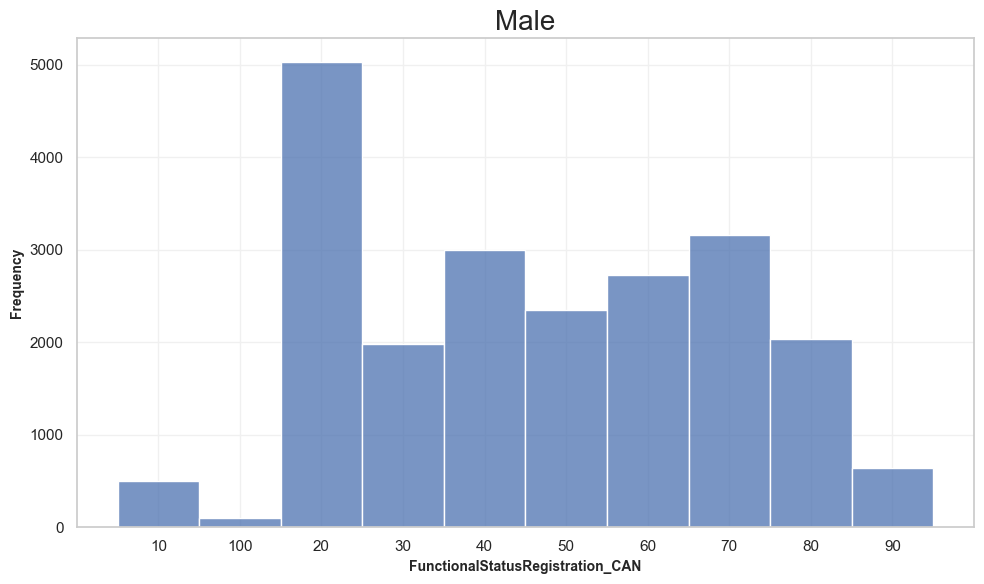

In [82]:
plot_histogram(df_m, features[0], bins=30, txt='Male', KDE=False)

In [83]:
u.check_informative_missingness(df_m, features[0], txt='Male')

╭─ ⚙ Informative Missingness Log: FunctionalStatusRegistration_CAN ──────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=708                1,182.4d                                    │
│    Known / Complete            Known=21,528                1,445.1d                                    │
│  Difference:            -262.7 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.2272 (Small)                                                                │
│  95% CI:                [-0.3021, -0.1524]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [84]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusRegistration_IsMissing'] = df_m [features[0]].isna().astype(int)
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].mode()[0]
)
# change datatype
df_m[features[0]] = df_m[features[0]].astype('category')
# sanity check
df_m.FunctionalStatusRegistration_IsMissing.sum()

np.int64(708)

#### Female

In [85]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusRegistration', cat=False)

✦ Feature Profiler │ Match: 'FunctionalStatusRegistration' │ Found: 
1                                                                   
╭──────────────────────────────────┬─────────┬────────┬─────┬──────╮
│ Feature                          │ Missing │ Unique │ Top │ Freq │
├──────────────────────────────────┼─────────┼────────┼─────┼──────┤
│ FunctionalStatusRegistration_CAN │     267 │     10 │  20 │ 1766 │
╰──────────────────────────────────┴─────────┴────────┴─────┴──────╯

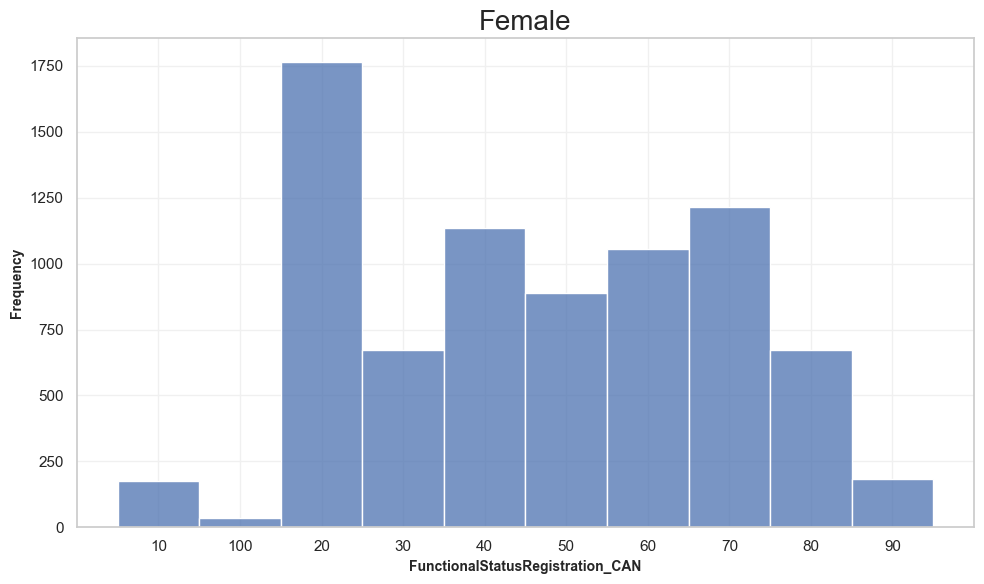

In [86]:
plot_histogram(df_f, features[0], bins=30, txt='Female', KDE=False)

In [87]:
u.check_informative_missingness(df_f, features[0], txt='Female')

╭─ ⚙ Informative Missingness Log: FunctionalStatusRegistration_CAN ──────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Female)                                                                              │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=267                1,212.7d                                    │
│    Known / Complete             Known=7,797                1,431.4d                                    │
│  Difference:            -218.7 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0013                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.1897 (Negligible)                                                           │
│  95% CI:                [-0.3117, -0.0677]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [88]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusRegistration_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusRegistration_IsMissing.sum()

np.int64(267)

## Functional Status Transplant

#### Male

In [89]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusTransplant', cat=True)

✦ Feature Profiler │ Match: 'FunctionalStatusTransplant' │ Found: 
1                                                                 
╭────────────────────────────────┬─────────┬────────┬─────┬──────╮
│ Feature                        │ Missing │ Unique │ Top │ Freq │
├────────────────────────────────┼─────────┼────────┼─────┼──────┤
│ FunctionalStatusTransplant_CAN │     983 │     10 │  20 │ 6348 │
╰────────────────────────────────┴─────────┴────────┴─────┴──────╯

╭──────────────────────────────── FunctionalStatusTransplant_CAN ────────────────────────────────╮
│ type:category │ cats:['10', '100', '20', '30', '40', '50', '60', '70', '80', '90'] │ ord:False │
╰────────────────────────────────────────────────────────────────────────────────────────────────╯

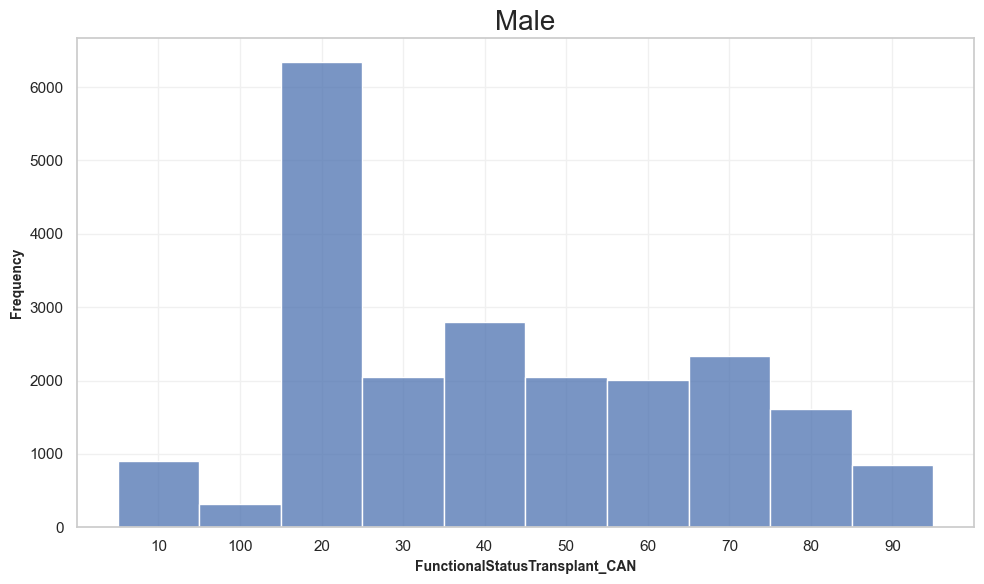

In [90]:
plot_histogram(df_m, features[0], bins=30, txt='Male', KDE=False)

In [91]:
u.check_informative_missingness(df_m, features[0], txt='Male')

╭─ ⚙ Informative Missingness Log: FunctionalStatusTransplant_CAN ────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=983                1,128.0d                                    │
│    Known / Complete            Known=21,253                1,451.0d                                    │
│  Difference:            -323.0 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.2796 (Small)                                                                │
│  95% CI:                [-0.3436, -0.2156]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [92]:
# impute: mode and use new feature for NANS
df_m['FunctionalStatusTransplant_IsMissing'] = df_m[features[0]].isna().astype(int)
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].mode()[0])
# change datatype
df_m[features[0]] = df_m[features[0]].astype('category')
# sanity check
df_m.FunctionalStatusTransplant_IsMissing.sum()

np.int64(983)

In [93]:
df_m[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.00000,0.47412
FunctionalStatusTransplant_CAN,0.47412,1.00000


#### Female

In [94]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusTransplant', cat=False)

✦ Feature Profiler │ Match: 'FunctionalStatusTransplant' │ Found: 
1                                                                 
╭────────────────────────────────┬─────────┬────────┬─────┬──────╮
│ Feature                        │ Missing │ Unique │ Top │ Freq │
├────────────────────────────────┼─────────┼────────┼─────┼──────┤
│ FunctionalStatusTransplant_CAN │     392 │     10 │  20 │ 2264 │
╰────────────────────────────────┴─────────┴────────┴─────┴──────╯

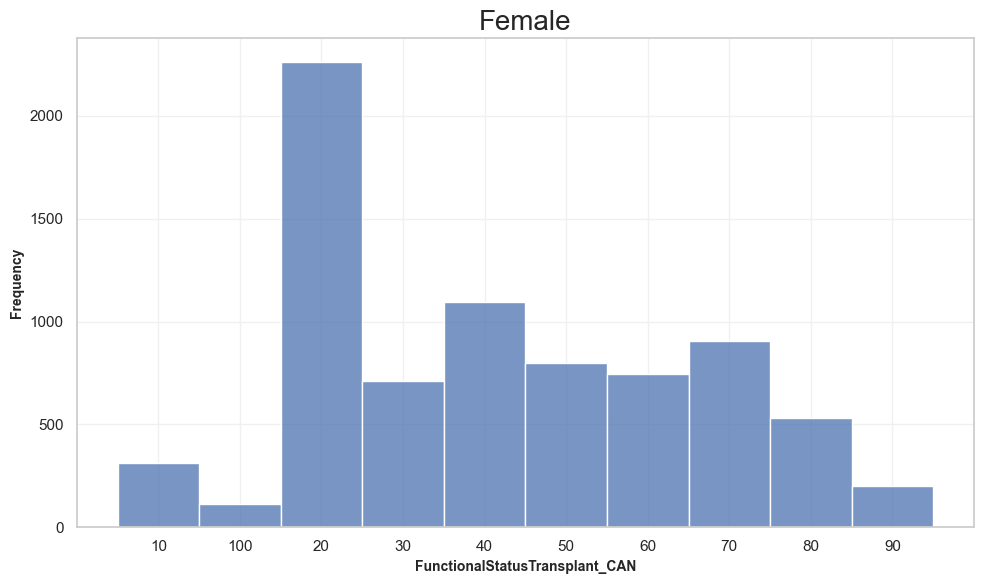

In [95]:
plot_histogram(df_f, features[0], bins=30, txt='Female', KDE=False)

In [96]:
u.check_informative_missingness(df_f, features[0], txt='Female')

╭─ ⚙ Informative Missingness Log: FunctionalStatusTransplant_CAN ────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Female)                                                                              │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing            Unknown=392                1,139.9d                                    │
│    Known / Complete             Known=7,672                1,438.7d                                    │
│  Difference:            -298.8 days                                                                    │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.2595 (Small)                                                                │
│  95% CI:                [-0.3610, -0.1579]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

#### The "Shadow Variable" (Indicator) + Mode Imputation

In [97]:
# impute: mode and use new feature for NANS
df_f['FunctionalStatusTransplant_IsMissing'] = df_f[features[0]].isna().astype(int)
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].mode()[0])
# change datatype
df_f[features[0]] = df_f[features[0]].astype('category')
# sanity check
df_f.FunctionalStatusTransplant_IsMissing.sum()

np.int64(392)

In [98]:
df_f[['FunctionalStatusRegistration_CAN', 'FunctionalStatusTransplant_CAN']].corr()

,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN
FunctionalStatusRegistration_CAN,1.000000,0.497816
FunctionalStatusTransplant_CAN,0.497816,1.000000


## Creatinine Registration
#### [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [99]:
# info
features = u.get_feature_info(df_m, 'CreatinineRegistration_CAN', cat=False)

✦ Feature Profiler │ Match: 'CreatinineRegistration_CAN' │ Found: 1                    
╭────────────────────────────┬─────────┬──────┬──────┬──────┬─────┬──────┬──────┬─────╮
│ Feature                    │ Missing │ Mean │  Std │  Min │ 25% │  50% │  75% │ Max │
├────────────────────────────┼─────────┼──────┼──────┼──────┼─────┼──────┼──────┼─────┤
│ CreatinineRegistration_CAN │      84 │ 1.43 │ 0.97 │ 0.08 │   1 │ 1.22 │ 1.54 │  24 │
╰────────────────────────────┴─────────┴──────┴──────┴──────┴─────┴──────┴──────┴─────╯

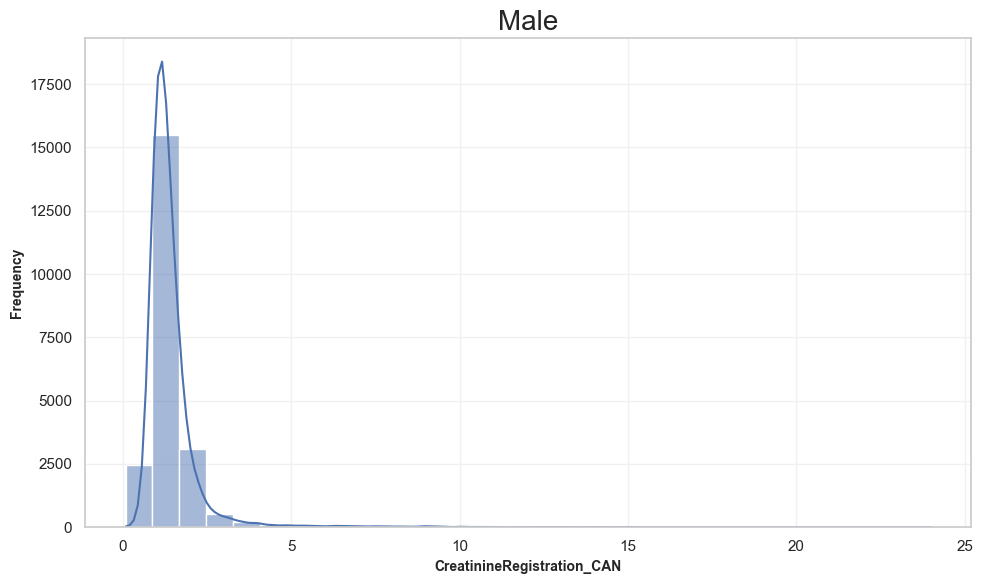

In [100]:
plot_histogram(df_m, features[0], bins=30, txt='Male')

In [101]:
u.check_informative_missingness(df_m, features[0], txt='Male')

╭─ ⚙ Informative Missingness Log: CreatinineRegistration_CAN ──────────────────────╮
│                                                                                  │
│  Cohort Overview (Male)                                                          │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing             Unknown=84                1,243.3d              │
│    Known / Complete            Known=22,152                1,437.5d              │
│  Difference:            -194.2 days                                              │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.1667                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.1678 (Negligible)                                     │
│  95% CI:                [-0.3821, 0.0464]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [102]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

╭─ CreatinineRegistration_CAN ─────────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.047    2.34e-12    0.222%                              │
│    Spearman    -0.060    5.54e-19    0.357%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Female

In [103]:
features = u.get_feature_info(df_f, 'CreatinineRegistration_CAN', cat=False)

✦ Feature Profiler │ Match: 'CreatinineRegistration_CAN' │ Found: 1                    
╭────────────────────────────┬─────────┬──────┬──────┬──────┬──────┬─────┬──────┬─────╮
│ Feature                    │ Missing │ Mean │  Std │  Min │  25% │ 50% │  75% │ Max │
├────────────────────────────┼─────────┼──────┼──────┼──────┼──────┼─────┼──────┼─────┤
│ CreatinineRegistration_CAN │      20 │ 1.18 │ 0.88 │ 0.19 │ 0.80 │   1 │ 1.30 │  21 │
╰────────────────────────────┴─────────┴──────┴──────┴──────┴──────┴─────┴──────┴─────╯

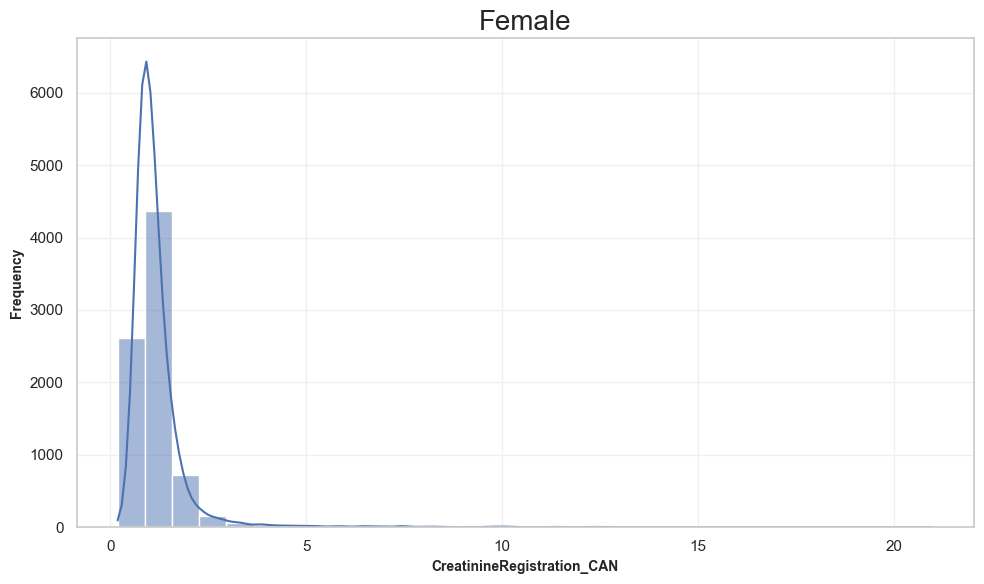

In [104]:
plot_histogram(df_f, features[0], bins=30, txt='Female')

In [105]:
u.check_informative_missingness(df_f, features[0], txt='Female')

╭─ ⚙ Informative Missingness Log: CreatinineRegistration_CAN ──────────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing             Unknown=20                1,713.4d              │
│    Known / Complete             Known=8,044                1,423.5d              │
│  Difference:            +289.9 days                                              │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.3218                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.2514 (Small)                                           │
│  95% CI:                [-0.1874, 0.6902]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [106]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

╭─ CreatinineRegistration_CAN ─────────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.054    1.46e-06    0.288%                              │
│    Spearman    -0.043    9.94e-05    0.188%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Log Transform

In [107]:
# Log Transform
df_m['CreatinineRegistration_Log'] = np.log1p(df_m[features[0]])
# female
df_f['CreatinineRegistration_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

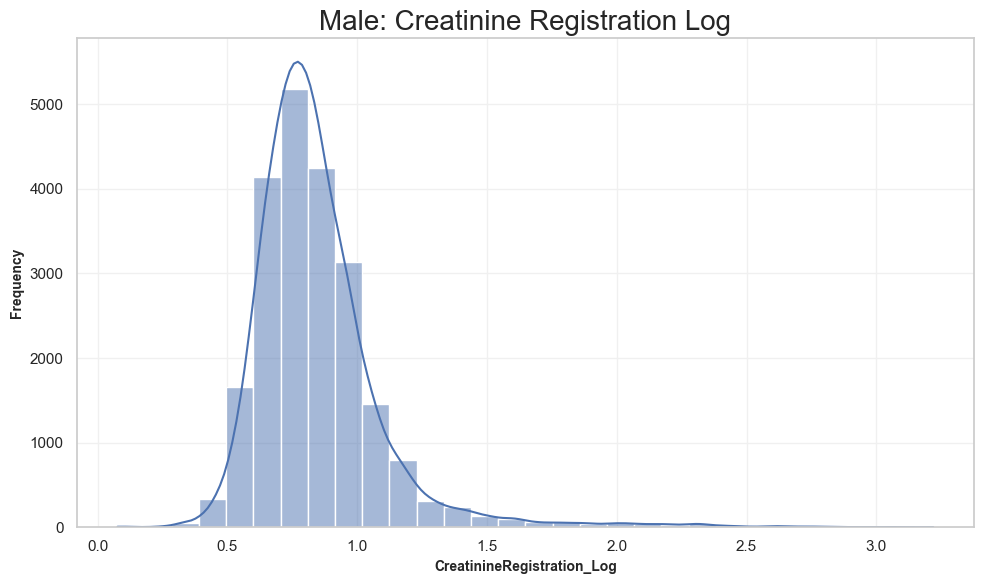

In [108]:
plot_histogram(df_m, 'CreatinineRegistration_Log', txt='Male: Creatinine Registration Log', bins=30)

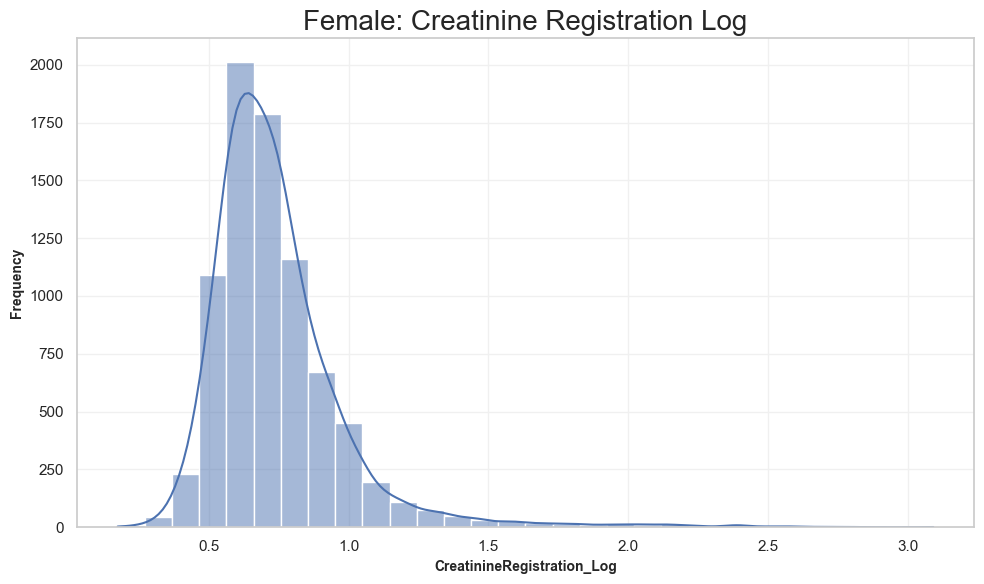

In [109]:
plot_histogram(df_f, 'CreatinineRegistration_Log', txt='Female: Creatinine Registration Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [110]:
# impute: median and use new feature for NANS
df_m['CreatinineRegistration_Log_IsMissing'] = df_m.CreatinineRegistration_Log.isna().astype(int)
# female
df_f['CreatinineRegistration_Log_IsMissing'] = df_f.CreatinineRegistration_Log.isna().astype(int)
# median
df_m['CreatinineRegistration_Log'] = df_m.CreatinineRegistration_Log.fillna(df_m.CreatinineRegistration_Log.median())
# female
df_f['CreatinineRegistration_Log'] = df_f.CreatinineRegistration_Log.fillna(df_f.CreatinineRegistration_Log.median())
# sanity check
df_m['CreatinineRegistration_Log_IsMissing'].sum(), df_f['CreatinineRegistration_Log_IsMissing'].sum()

(np.int64(84), np.int64(20))

## Creatinine Transplant

#### Male

In [111]:
# info
features = u.get_feature_info(df_m, 'CreatinineTransplant_CAN', cat=False)

✦ Feature Profiler │ Match: 'CreatinineTransplant_CAN' │ Found: 1                    
╭──────────────────────────┬─────────┬──────┬──────┬──────┬─────┬──────┬──────┬─────╮
│ Feature                  │ Missing │ Mean │  Std │  Min │ 25% │  50% │  75% │ Max │
├──────────────────────────┼─────────┼──────┼──────┼──────┼─────┼──────┼──────┼─────┤
│ CreatinineTransplant_CAN │      41 │ 1.43 │ 0.99 │ 0.06 │   1 │ 1.24 │ 1.57 │  37 │
╰──────────────────────────┴─────────┴──────┴──────┴──────┴─────┴──────┴──────┴─────╯

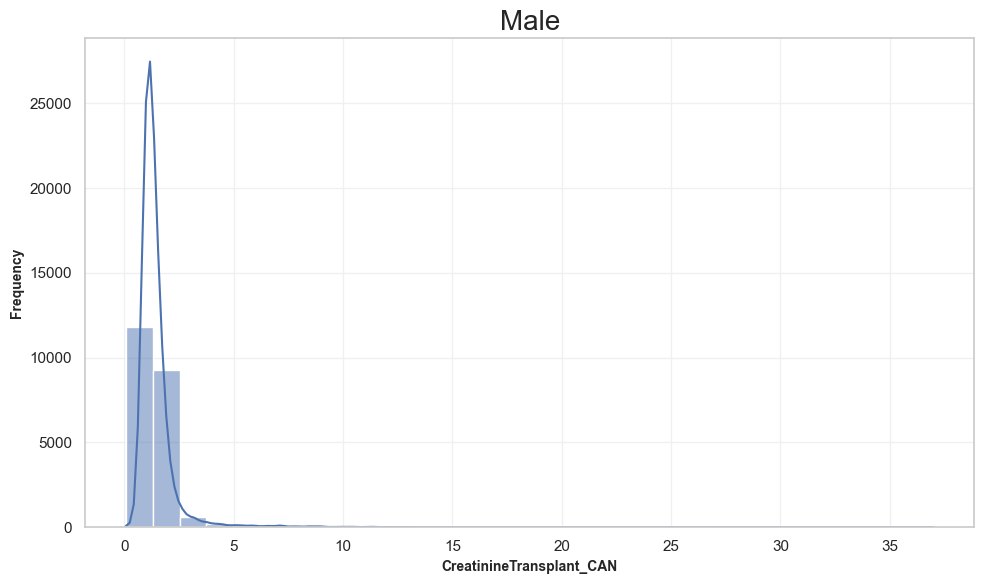

In [112]:
plot_histogram(df_m, features[0], bins=30, txt='Male')

In [113]:
u.check_informative_missingness(df_m, features[0], txt='Male')

╭─ ⚙ Informative Missingness Log: CreatinineTransplant_CAN ──────────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Male)                                                                                │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing             Unknown=41                  174.6d                                    │
│    Known / Complete            Known=22,195                1,439.1d                                    │
│  Difference:            -1,264.5 days                                                                  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -1.0941 (Large)                                                                │
│  95% CI:                [-1.4006, -0.7875]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [114]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Female')

╭─ CreatinineTransplant_CAN ───────────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.037    3.70e-08    0.136%                              │
│    Spearman    -0.041    6.79e-10    0.171%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Female

In [115]:
# info
features = u.get_feature_info(df_f, 'CreatinineTransplant_CAN', cat=False)

✦ Feature Profiler │ Match: 'CreatinineTransplant_CAN' │ Found: 1                    
╭──────────────────────────┬─────────┬──────┬──────┬──────┬──────┬─────┬──────┬─────╮
│ Feature                  │ Missing │ Mean │  Std │  Min │  25% │ 50% │  75% │ Max │
├──────────────────────────┼─────────┼──────┼──────┼──────┼──────┼─────┼──────┼─────┤
│ CreatinineTransplant_CAN │      14 │ 1.20 │ 0.98 │ 0.13 │ 0.80 │   1 │ 1.30 │  24 │
╰──────────────────────────┴─────────┴──────┴──────┴──────┴──────┴─────┴──────┴─────╯

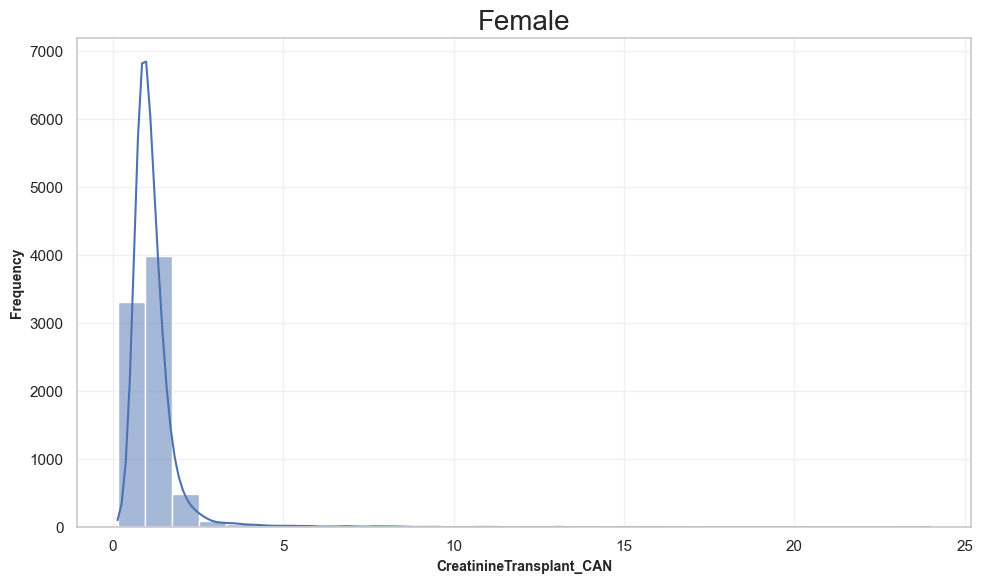

In [116]:
plot_histogram(df_f, features[0], bins=30, txt='Female')

In [117]:
u.check_informative_missingness(df_f, features[0], txt='Female')

╭─ ⚙ Informative Missingness Log: CreatinineTransplant_CAN ──────────────────────────────────────────────╮
│                                                                                                        │
│  Cohort Overview (Female)                                                                              │
│    Cohort Group                 Group Sizes           Mean Survival                                    │
│    Unknown / Missing             Unknown=14                  303.6d                                    │
│    Known / Complete             Known=8,050                1,426.1d                                    │
│  Difference:            -1,122.5 days                                                                  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Welch's t-test Analysis                                                                               │
│  ρ-Value:               0.0000                                                                         │
│                                                                                                        │
│  ⚠ INFORMATIVE MISSINGNESS DETECTED                                                                    │
│  Statistical Significance: Not MCAR. Likely MAR or MNAR (Missingness pattern affects target profile).  │
│                                                                                                        │
│  ──────────────────────────────────────────────────────────                                            │
│                                                                                                        │
│  Cohen's Analysis                                                                                      │
│  Cohen's d:             -0.9740 (Large)                                                                │
│  95% CI:                [-1.4984, -0.4495]                                                             │
│                                                                                                        │
│  Result: INFORMATIVE MISSINGNESS (statistically significant difference)                                │
│                                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [118]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

╭─ CreatinineTransplant_CAN ───────────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Female)                                     │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.052    3.63e-06    0.266%                              │
│    Spearman    -0.036    1.29e-03    0.129%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Log Transform

In [119]:
# Log Transform
df_m['CreatinineTransplant_Log'] = np.log1p(df_m[features[0]])
# female
df_f['CreatinineTransplant_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

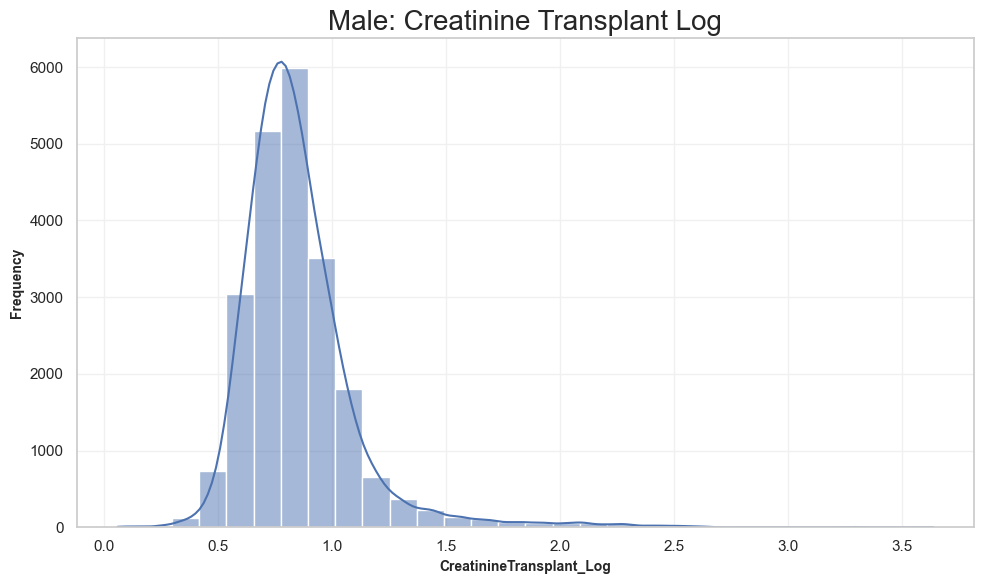

In [120]:
plot_histogram(df_m, 'CreatinineTransplant_Log', txt='Male: Creatinine Transplant Log', bins=30)

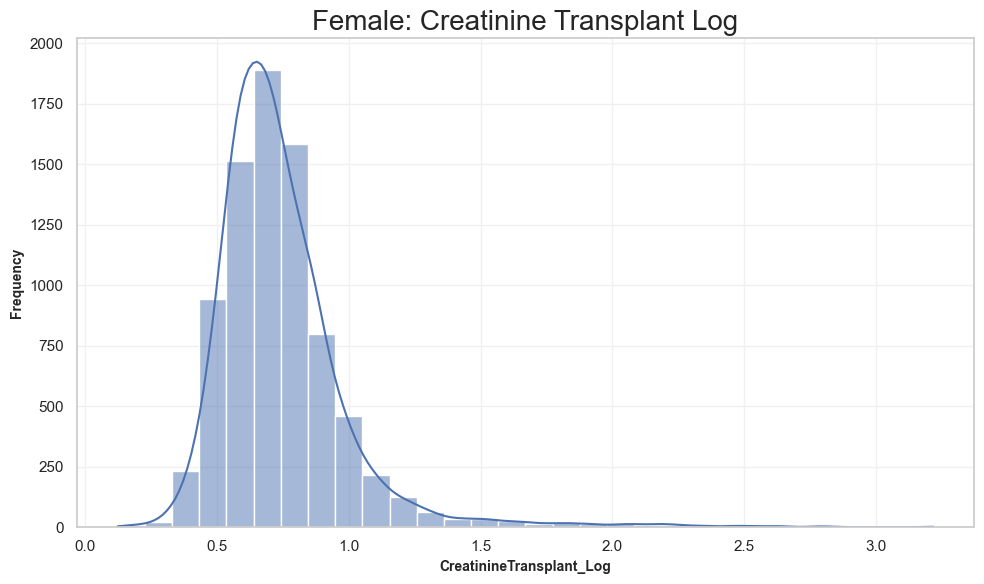

In [121]:
plot_histogram(df_f, 'CreatinineTransplant_Log', txt='Female: Creatinine Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [122]:
# impute: median and use new feature for NANS
df_m['CreatinineTransplant_Log_IsMissing'] = df_m.CreatinineTransplant_Log.isna().astype(int)
# female
df_f['CreatinineTransplant_Log_IsMissing'] = df_f.CreatinineTransplant_Log.isna().astype(int)
# median
df_m['CreatinineTransplant_Log'] = df_m.CreatinineTransplant_Log.fillna(df_m.CreatinineTransplant_Log.median())
# female
df_f['CreatinineTransplant_Log'] = df_f.CreatinineTransplant_Log.fillna(df_f.CreatinineTransplant_Log.median())
# sanity check
df_m['CreatinineTransplant_Log_IsMissing'].sum(), df_f['CreatinineTransplant_Log_IsMissing'].sum()

(np.int64(41), np.int64(14))

In [123]:
# correlation
df_m[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.686799
CreatinineTransplant_Log,0.686799,1.000000


In [124]:
# correlation
df_f[['CreatinineRegistration_Log', 'CreatinineTransplant_Log']].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.694744
CreatinineTransplant_Log,0.694744,1.000000


In [125]:
# info
features = u.get_feature_info(df_m, r'^Creatinine.*_Log$' , cat=False) 

✦ Feature Profiler │ Match: '^Creatinine.*_Log$' │ Found: 2                              
╭────────────────────────────┬─────────┬──────┬──────┬──────┬──────┬──────┬──────┬──────╮
│ Feature                    │ Missing │ Mean │  Std │  Min │  25% │  50% │  75% │  Max │
├────────────────────────────┼─────────┼──────┼──────┼──────┼──────┼──────┼──────┼──────┤
│ CreatinineRegistration_Log │       0 │ 0.85 │ 0.25 │ 0.08 │ 0.69 │ 0.80 │ 0.93 │ 3.22 │
│ CreatinineTransplant_Log   │       0 │ 0.85 │ 0.25 │ 0.06 │ 0.69 │ 0.81 │ 0.94 │ 3.64 │
╰────────────────────────────┴─────────┴──────┴──────┴──────┴──────┴──────┴──────┴──────╯

In [126]:
df_m[features].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.686799
CreatinineTransplant_Log,0.686799,1.000000


In [127]:
df_f[features].corr()

,CreatinineRegistration_Log,CreatinineTransplant_Log
CreatinineRegistration_Log,1.000000,0.694744
CreatinineTransplant_Log,0.694744,1.000000


#### PCA

In [128]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "creatinine_log")
df_f = apply_pca_feature_engineering(df_f, features, "creatinine_log")

[creatinine_log] Retained 2 components (100.00% variance explained)
[creatinine_log] Retained 2 components (100.00% variance explained)


## TotalBilirubin Transplant
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [129]:
# info
features = u.get_feature_info(df_m, 'TotalBilirubinTransplant', cat=False) 

✦ Feature Profiler │ Match: 'TotalBilirubinTransplant' │ Found: 1                         
╭──────────────────────────────┬─────────┬──────┬──────┬──────┬──────┬──────┬──────┬─────╮
│ Feature                      │ Missing │ Mean │  Std │  Min │  25% │  50% │  75% │ Max │
├──────────────────────────────┼─────────┼──────┼──────┼──────┼──────┼──────┼──────┼─────┤
│ TotalBilirubinTransplant_CAN │      83 │ 1.03 │ 1.70 │ 0.10 │ 0.50 │ 0.70 │ 1.10 │  61 │
╰──────────────────────────────┴─────────┴──────┴──────┴──────┴──────┴──────┴──────┴─────╯

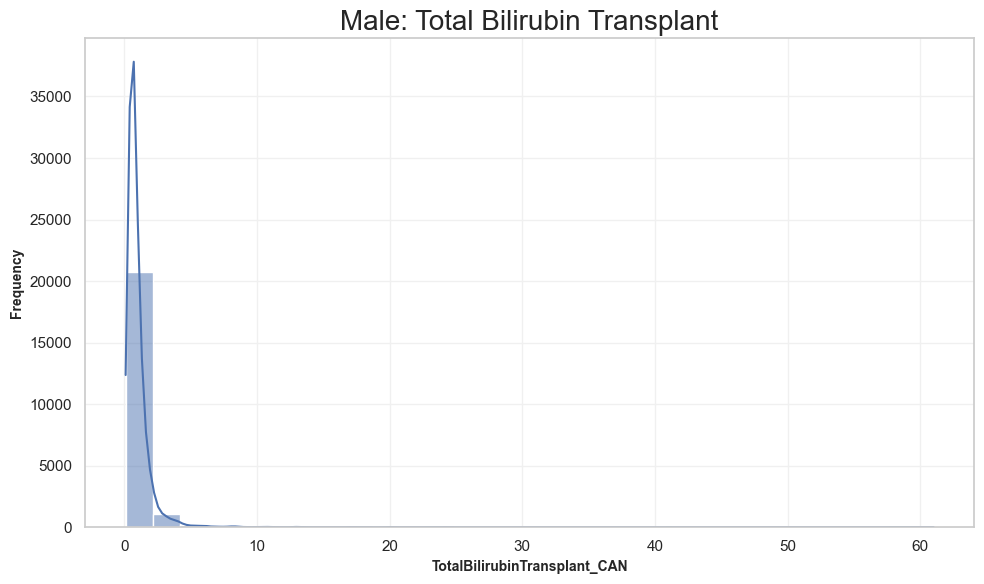

In [130]:
plot_histogram(df_m, features[0], txt='Male: Total Bilirubin Transplant', bins=30)

In [131]:
u.check_informative_missingness(df_m, features[0], txt='Male')

╭─ ⚙ Informative Missingness Log: TotalBilirubinTransplant_CAN ────────────────────╮
│                                                                                  │
│  Cohort Overview (Male)                                                          │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing             Unknown=83                1,248.4d              │
│    Known / Complete            Known=22,153                1,437.5d              │
│  Difference:            -189.0 days                                              │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.2547                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             -0.1634 (Negligible)                                     │
│  95% CI:                [-0.3789, 0.0522]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [132]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

╭─ TotalBilirubinTransplant_CAN ───────────────────────────────────────────╮
│                                                                          │
│  Predictive Metrics Summary (Male)                                       │
│                                                                          │
│    Metric           r           p        R²                              │
│    Pearson     -0.040    2.66e-09    0.160%                              │
│    Spearman    +0.001    9.40e-01    0.000%                              │
│                                                                          │
│  ✔ Significant relationship                                              │
│  Feature shows a linear negative directional association with survival.  │
│                                                                          │
╰──────────────────────────────────────────────────────────────────────────╯

#### Female

In [133]:
# info
features = u.get_feature_info(df_f, 'TotalBilirubinTransplant', cat=False) 

✦ Feature Profiler │ Match: 'TotalBilirubinTransplant' │ Found: 1                        
╭──────────────────────────────┬─────────┬──────┬──────┬──────┬──────┬──────┬─────┬─────╮
│ Feature                      │ Missing │ Mean │  Std │  Min │  25% │  50% │ 75% │ Max │
├──────────────────────────────┼─────────┼──────┼──────┼──────┼──────┼──────┼─────┼─────┤
│ TotalBilirubinTransplant_CAN │      35 │ 0.90 │ 1.68 │ 0.10 │ 0.40 │ 0.60 │   1 │  80 │
╰──────────────────────────────┴─────────┴──────┴──────┴──────┴──────┴──────┴─────┴─────╯

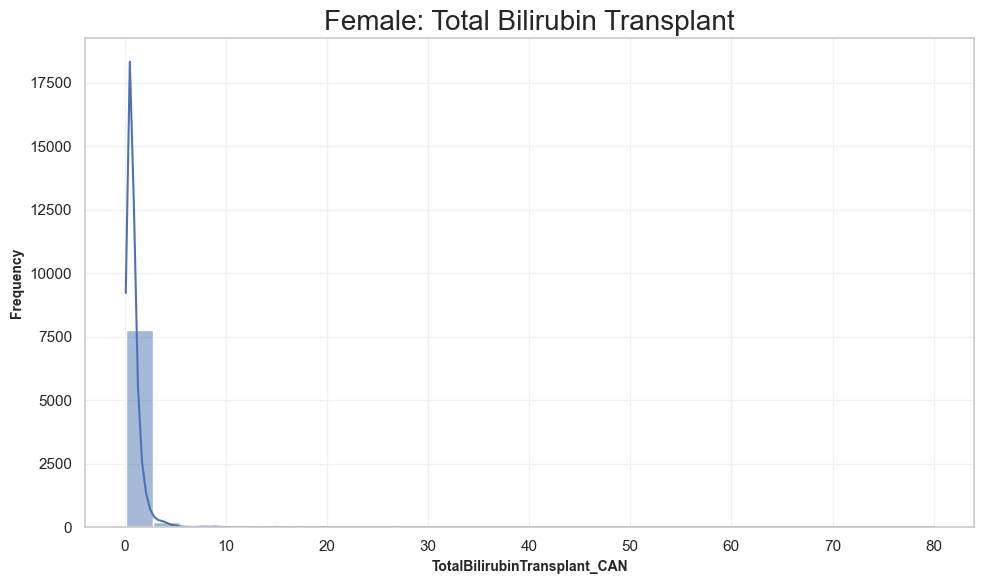

In [134]:
plot_histogram(df_f, features[0], txt='Female: Total Bilirubin Transplant', bins=30)

In [135]:
u.check_informative_missingness(df_f, features[0], txt='Female')

╭─ ⚙ Informative Missingness Log: TotalBilirubinTransplant_CAN ────────────────────╮
│                                                                                  │
│  Cohort Overview (Female)                                                        │
│    Cohort Group                 Group Sizes           Mean Survival              │
│    Unknown / Missing             Unknown=35                1,525.4d              │
│    Known / Complete             Known=8,029                1,423.7d              │
│  Difference:            +101.7 days                                              │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Welch's t-test Analysis                                                         │
│  ρ-Value:               0.6805                                                   │
│                                                                                  │
│  ✔ RANDOM MISSINGNESS DETECTED                                                   │
│  Statistical Significance: Consistent with MCAR (Missing Completely at Random).  │
│                                                                                  │
│  ──────────────────────────────────────────────────────────                      │
│                                                                                  │
│  Cohen's Analysis                                                                │
│  Cohen's d:             0.0882 (Negligible)                                      │
│  95% CI:                [-0.2439, 0.4202]                                        │
│                                                                                  │
│  Result: Likely Random Missingness (Effect size not significant)                 │
│                                                                                  │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [136]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

╭─ TotalBilirubinTransplant_CAN ─────────────────╮
│                                                │
│  Predictive Metrics Summary (Female)           │
│                                                │
│    Metric           r           p        R²    │
│    Pearson     -0.015    1.72e-01    0.023%    │
│    Spearman    +0.017    1.35e-01    0.028%    │
│                                                │
│  ✖ No strong relationship                      │
│  Pattern consistent with random variation.     │
│                                                │
╰────────────────────────────────────────────────╯

#### Log Transform

In [137]:
# Log Transform
df_m['TotalBilirubinTransplant_Log'] = np.log1p(df_m[features[0]])
# female
df_f['TotalBilirubinTransplant_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

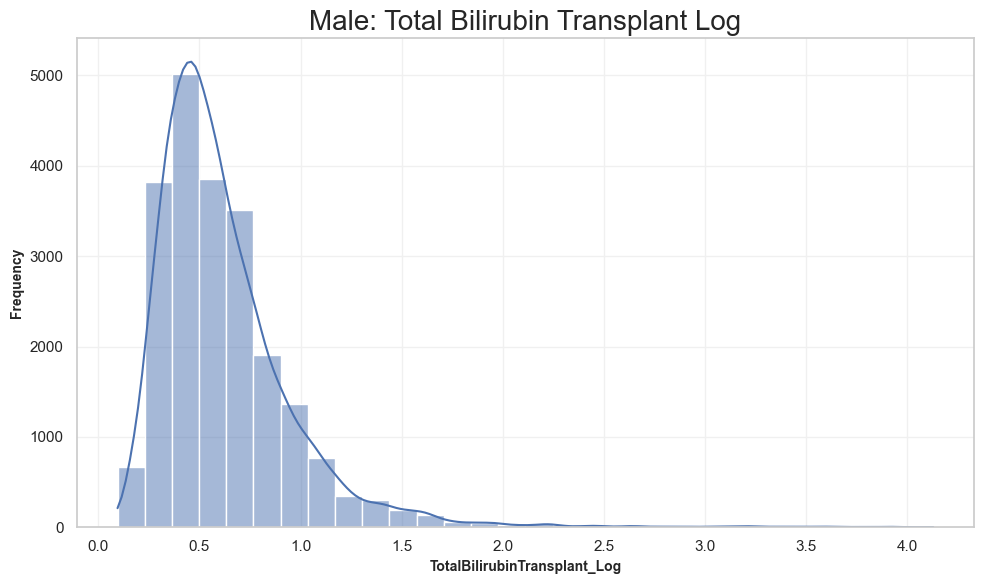

In [138]:
plot_histogram(df_m, 'TotalBilirubinTransplant_Log', txt='Male: Total Bilirubin Transplant Log', bins=30)

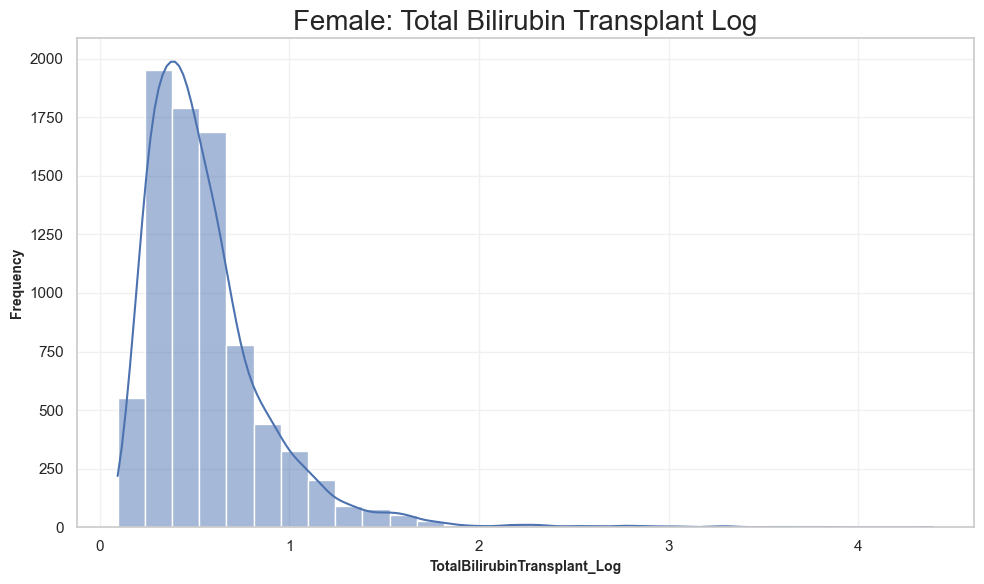

In [139]:
plot_histogram(df_f, 'TotalBilirubinTransplant_Log', txt='Female: Total Bilirubin Transplant Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [140]:
# impute: median and use new feature for NANS
df_m['TotalBilirubinTransplant_Log_IsMissing'] = df_m.TotalBilirubinTransplant_Log.isna().astype(int)
# female
df_f['TotalBilirubinTransplant_Log_IsMissing'] = df_f.TotalBilirubinTransplant_Log.isna().astype(int)
# median
df_m['TotalBilirubinTransplant_Log'] = df_m.TotalBilirubinTransplant_Log.fillna(df_m.TotalBilirubinTransplant_Log.median())
# female
df_f['TotalBilirubinTransplant_Log'] = df_f.TotalBilirubinTransplant_Log.fillna(df_f.TotalBilirubinTransplant_Log.median())
# sanity check
df_m['TotalBilirubinTransplant_Log_IsMissing'].sum(), df_f['TotalBilirubinTransplant_Log_IsMissing'].sum()

(np.int64(83), np.int64(35))

## BMI
$ \text{Metric System:} \space \text{Weight(kg)} \space / \space \text{Height(m)}^2$

### Male

In [141]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

✦ Feature Profiler │ Match: 'BMI_' │ Found: 4                                                   
╭──────────────────────┬─────────┬───────┬─────────┬───────┬───────┬───────┬───────┬───────────╮
│ Feature              │ Missing │  Mean │     Std │   Min │   25% │   50% │   75% │       Max │
├──────────────────────┼─────────┼───────┼─────────┼───────┼───────┼───────┼───────┼───────────┤
│ BMI_Calc_CAN         │       8 │ 27.71 │    4.78 │ 15.10 │ 24.30 │ 27.40 │    31 │     52.80 │
│ BMI_Listing_CALC_CAN │      26 │ 27.69 │    4.74 │ 12.80 │ 24.20 │ 27.40 │    31 │     68.30 │
│ BMI_Listing_CAN      │      84 │ 68.61 │ 3336.78 │  2.98 │ 24.22 │ 27.43 │ 31.02 │ 318008.31 │
│ BMI_Removal_CAN      │       8 │ 27.69 │    4.67 │    15 │ 24.30 │ 27.40 │    31 │     48.70 │
╰──────────────────────┴─────────┴───────┴─────────┴───────┴───────┴───────┴───────┴───────────╯

In [142]:
# check BMI unrealistic data
df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
4241,26.2,24.6,169.1919,24.6,68.7,167.0
14070,34.0,36.4,33257.9995,36.4,132.0,190.5
16633,24.8,30.1,276457.0637,27.7,103.4,185.4
16710,24.5,25.8,260207.6125,25.8,74.8,170.2
17252,32.8,33.4,318008.3102,32.8,114.8,185.4
21917,20.5,20.3,18611.1111,20.3,68.0,182.9


In [143]:
# get index and recalc BMI_Listing_CAN
idx = df_m.loc[df_m.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [144]:
# sanity check
df_m.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
4241,26.2,24.6,24.6334,24.6,68.7,167.0
14070,34.0,36.4,36.3734,36.4,132.0,190.5
16633,24.8,30.1,30.0816,27.7,103.4,185.4
16710,24.5,25.8,25.8216,25.8,74.8,170.2
17252,32.8,33.4,33.3982,32.8,114.8,185.4
21917,20.5,20.3,20.3274,20.3,68.0,182.9


In [145]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

✦ Feature Profiler │ Match: 'BMI_' │ Found: 4                                            
╭──────────────────────┬─────────┬───────┬──────┬───────┬───────┬───────┬───────┬───────╮
│ Feature              │ Missing │  Mean │  Std │   Min │   25% │   50% │   75% │   Max │
├──────────────────────┼─────────┼───────┼──────┼───────┼───────┼───────┼───────┼───────┤
│ BMI_Calc_CAN         │       8 │ 27.71 │ 4.78 │ 15.10 │ 24.30 │ 27.40 │    31 │ 52.80 │
│ BMI_Listing_CALC_CAN │      26 │ 27.69 │ 4.74 │ 12.80 │ 24.20 │ 27.40 │    31 │ 68.30 │
│ BMI_Listing_CAN      │      84 │ 27.69 │ 4.80 │  2.98 │ 24.22 │ 27.43 │ 31.01 │ 79.74 │
│ BMI_Removal_CAN      │       8 │ 27.69 │ 4.67 │    15 │ 24.30 │ 27.40 │    31 │ 48.70 │
╰──────────────────────┴─────────┴───────┴──────┴───────┴───────┴───────┴───────┴───────╯

In [146]:
df_m[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.855406,0.849010,0.897447
BMI_Listing_CALC_CAN,0.855406,1.000000,0.989740,0.940109
BMI_Listing_CAN,0.849010,0.989740,1.000000,0.929042
BMI_Removal_CAN,0.897447,0.940109,0.929042,1.000000


In [147]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_CAN'] /
    (df_m.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [148]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [149]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_m.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [150]:
# Use height & weight to calculate BMI
idx = df_m.loc[df_m.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_m.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_m.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_m.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [151]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

✦ Feature Profiler │ Match: 'BMI_' │ Found: 4                                            
╭──────────────────────┬─────────┬───────┬──────┬───────┬───────┬───────┬───────┬───────╮
│ Feature              │ Missing │  Mean │  Std │   Min │   25% │   50% │   75% │   Max │
├──────────────────────┼─────────┼───────┼──────┼───────┼───────┼───────┼───────┼───────┤
│ BMI_Calc_CAN         │       2 │ 27.71 │ 4.78 │ 14.10 │ 24.30 │ 27.40 │    31 │ 52.80 │
│ BMI_Listing_CALC_CAN │      11 │ 27.68 │ 4.75 │ 12.70 │ 24.20 │ 27.40 │    31 │ 68.30 │
│ BMI_Listing_CAN      │       0 │ 27.68 │ 4.80 │  2.98 │ 24.22 │ 27.42 │ 31.01 │ 79.74 │
│ BMI_Removal_CAN      │       2 │ 27.69 │ 4.67 │    14 │ 24.30 │ 27.40 │    31 │ 48.70 │
╰──────────────────────┴─────────┴───────┴──────┴───────┴───────┴───────┴───────┴───────╯

### Female

In [152]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

✦ Feature Profiler │ Match: 'BMI_' │ Found: 4                                                 
╭──────────────────────┬─────────┬───────┬────────┬───────┬───────┬───────┬───────┬──────────╮
│ Feature              │ Missing │  Mean │    Std │   Min │   25% │   50% │   75% │      Max │
├──────────────────────┼─────────┼───────┼────────┼───────┼───────┼───────┼───────┼──────────┤
│ BMI_Calc_CAN         │       5 │ 26.92 │   5.43 │ 15.10 │ 22.70 │ 26.50 │ 30.90 │    48.80 │
│ BMI_Listing_CALC_CAN │      17 │ 26.81 │   5.35 │ 15.20 │ 22.70 │ 26.30 │ 30.70 │    51.90 │
│ BMI_Listing_CAN      │      31 │ 32.04 │ 335.10 │  9.23 │ 22.66 │ 26.34 │ 30.73 │ 23981.82 │
│ BMI_Removal_CAN      │       5 │ 26.82 │   5.33 │ 15.20 │ 22.70 │ 26.40 │ 30.70 │    46.20 │
╰──────────────────────┴─────────┴───────┴────────┴───────┴───────┴───────┴───────┴──────────╯

In [153]:
# check BMI unrealistic data
df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
14479,21.2,19.5,18140.000,19.5,45.4,152.4
21940,27.9,26.6,23981.824,26.6,74.8,167.6


In [154]:
# get index and recalc BMI_Listing_CAN
idx = df_f.loc[df_f.BMI_Listing_CAN > 100, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)
# sanity check
df_f.loc[idx, features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']]

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN,Weight_kg_Listing_CAN,Height_cm_Listing_CAN
14479,21.2,19.5,19.5473,19.5,45.4,152.4
21940,27.9,26.6,26.6289,26.6,74.8,167.6


In [155]:
df_f[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.890495,0.890123,0.919668
BMI_Listing_CALC_CAN,0.890495,1.000000,0.996153,0.959284
BMI_Listing_CAN,0.890123,0.996153,1.000000,0.955792
BMI_Removal_CAN,0.919668,0.959284,0.955792,1.000000


In [156]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Calc_CAN.isna(), features + ['Weight_kg_CAN', 'Height_cm_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Calc_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_CAN'] /
    (df_f.loc[idx, 'Height_cm_CAN'] / 100) ** 2,
    1)

In [157]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CALC_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CALC_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    1)

In [158]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Listing_CAN.isna(), features + ['Weight_kg_Listing_CAN', 'Height_cm_Listing_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Listing_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Listing_CAN'] /
    (df_f.loc[idx, 'Height_cm_Listing_CAN'] / 100) ** 2,
    4)

In [159]:
# Use height & weight to calculate BMI
idx = df_f.loc[df_f.BMI_Removal_CAN.isna(), features + ['Weight_kg_Removal_CAN', 'Height_cm_Removal_CAN']].index
# update with correct BMI
df_f.loc[idx, 'BMI_Removal_CAN']  = np.round(
    df_f.loc[idx, 'Weight_kg_Removal_CAN'] /
    (df_f.loc[idx, 'Height_cm_Removal_CAN'] / 100) ** 2,
    1)

In [160]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

✦ Feature Profiler │ Match: 'BMI_' │ Found: 4                                            
╭──────────────────────┬─────────┬───────┬──────┬───────┬───────┬───────┬───────┬───────╮
│ Feature              │ Missing │  Mean │  Std │   Min │   25% │   50% │   75% │   Max │
├──────────────────────┼─────────┼───────┼──────┼───────┼───────┼───────┼───────┼───────┤
│ BMI_Calc_CAN         │       5 │ 26.92 │ 5.43 │ 15.10 │ 22.70 │ 26.50 │ 30.90 │ 48.80 │
│ BMI_Listing_CALC_CAN │      12 │ 26.80 │ 5.36 │ 12.90 │ 22.70 │ 26.30 │ 30.70 │ 51.90 │
│ BMI_Listing_CAN      │       1 │ 26.79 │ 5.38 │  9.23 │ 22.66 │ 26.33 │ 30.73 │ 50.00 │
│ BMI_Removal_CAN      │       5 │ 26.82 │ 5.33 │ 15.20 │ 22.70 │ 26.40 │ 30.70 │ 46.20 │
╰──────────────────────┴─────────┴───────┴──────┴───────┴───────┴───────┴───────┴───────╯

### Median

In [161]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

In [162]:
df_m[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.853452,0.848935,0.897667
BMI_Listing_CALC_CAN,0.853452,1.000000,0.984295,0.937733
BMI_Listing_CAN,0.848935,0.984295,1.000000,0.928883
BMI_Removal_CAN,0.897667,0.937733,0.928883,1.000000


In [163]:
df_f[features].corr()

,BMI_Calc_CAN,BMI_Listing_CALC_CAN,BMI_Listing_CAN,BMI_Removal_CAN
BMI_Calc_CAN,1.000000,0.889103,0.888480,0.919207
BMI_Listing_CALC_CAN,0.889103,1.000000,0.991720,0.958224
BMI_Listing_CAN,0.888480,0.991720,1.000000,0.954279
BMI_Removal_CAN,0.919207,0.958224,0.954279,1.000000


#### PCA

In [164]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "BMI")
df_f = apply_pca_feature_engineering(df_f, features, "BMI")

[BMI] Retained 1 components (93.17% variance explained)
[BMI] Retained 1 components (95.04% variance explained)


## Weight (Kg)

### Male

In [165]:
# info
features = u.get_feature_info(df_m, 'Weight', cat=False) 

✦ Feature Profiler │ Match: 'Weight' │ Found: 4                                                   
╭─────────────────────────────┬─────────┬───────┬───────┬───────┬───────┬───────┬───────┬────────╮
│ Feature                     │ Missing │  Mean │   Std │   Min │   25% │   50% │   75% │    Max │
├─────────────────────────────┼─────────┼───────┼───────┼───────┼───────┼───────┼───────┼────────┤
│ Weight_kg_CAN               │       2 │ 87.54 │ 17.21 │ 29.50 │ 75.30 │ 86.20 │    99 │ 162.10 │
│ Weight_kg_Listing_CAN       │      11 │ 87.51 │ 17.15 │    12 │ 75.10 │ 86.40 │ 99.20 │ 182.50 │
│ Weight_kg_Registrsation_CAN │      34 │ 87.53 │ 17.31 │  9.98 │ 75.08 │ 86.50 │ 99.28 │    271 │
│ Weight_kg_Removal_CAN       │       2 │ 87.52 │ 16.94 │ 29.20 │ 75.30 │ 86.60 │ 98.90 │ 165.10 │
╰─────────────────────────────┴─────────┴───────┴───────┴───────┴───────┴───────┴───────┴────────╯

In [166]:
df_m[features].corr()

,Weight_kg_CAN,Weight_kg_Listing_CAN,Weight_kg_Registrsation_CAN,Weight_kg_Removal_CAN
Weight_kg_CAN,1.000000,0.896918,0.892894,0.929657
Weight_kg_Listing_CAN,0.896918,1.000000,0.993187,0.954221
Weight_kg_Registrsation_CAN,0.892894,0.993187,1.000000,0.947825
Weight_kg_Removal_CAN,0.929657,0.954221,0.947825,1.000000


### Female

In [167]:
# info
features = u.get_feature_info(df_f, 'Weight', cat=False) 

✦ Feature Profiler │ Match: 'Weight' │ Found: 4                                                   
╭─────────────────────────────┬─────────┬───────┬───────┬───────┬───────┬───────┬───────┬────────╮
│ Feature                     │ Missing │  Mean │   Std │   Min │   25% │   50% │   75% │    Max │
├─────────────────────────────┼─────────┼───────┼───────┼───────┼───────┼───────┼───────┼────────┤
│ Weight_kg_CAN               │       5 │ 71.82 │ 15.94 │ 31.90 │ 59.60 │ 70.30 │ 82.70 │    148 │
│ Weight_kg_Listing_CAN       │      11 │ 71.56 │ 15.77 │ 32.50 │ 59.40 │    70 │ 82.10 │ 143.30 │
│ Weight_kg_Registrsation_CAN │      16 │ 71.54 │ 15.85 │ 25.95 │ 59.42 │ 70.09 │ 82.10 │ 143.34 │
│ Weight_kg_Removal_CAN       │       5 │ 71.55 │ 15.69 │ 32.50 │ 59.40 │ 70.30 │ 82.20 │ 143.30 │
╰─────────────────────────────┴─────────┴───────┴───────┴───────┴───────┴───────┴───────┴────────╯

In [168]:
df_f[features].corr()

,Weight_kg_CAN,Weight_kg_Listing_CAN,Weight_kg_Registrsation_CAN,Weight_kg_Removal_CAN
Weight_kg_CAN,1.000000,0.919282,0.918192,0.942370
Weight_kg_Listing_CAN,0.919282,1.000000,0.998342,0.968052
Weight_kg_Registrsation_CAN,0.918192,0.998342,1.000000,0.965822
Weight_kg_Removal_CAN,0.942370,0.968052,0.965822,1.000000


### Median

In [169]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

#### PCA

In [170]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "weight")
df_f = apply_pca_feature_engineering(df_f, features, "weight")

[weight] Retained 1 components (95.09% variance explained)
[weight] Retained 1 components (96.28% variance explained)


## Height

### Male

In [171]:
# info
features = u.get_feature_info(df_m, 'Height', cat=False)

✦ Feature Profiler │ Match: 'Height' │ Found: 4                                                   
╭────────────────────────────┬─────────┬────────┬──────┬─────┬────────┬────────┬────────┬────────╮
│ Feature                    │ Missing │   Mean │  Std │ Min │    25% │    50% │    75% │    Max │
├────────────────────────────┼─────────┼────────┼──────┼─────┼────────┼────────┼────────┼────────┤
│ Height_cm_CAN              │       0 │ 177.52 │ 7.96 │ 124 │ 172.70 │ 177.80 │ 182.90 │ 210.80 │
│ Height_cm_Listing_CAN      │       0 │ 177.58 │ 7.99 │  97 │ 172.70 │ 177.80 │ 182.90 │    221 │
│ Height_cm_Registration_CAN │      82 │ 177.54 │ 8.41 │   2 │    173 │    178 │    183 │    221 │
│ Height_cm_Removal_CAN      │       0 │ 177.55 │ 7.90 │ 124 │ 172.70 │ 177.80 │ 182.90 │ 213.40 │
╰────────────────────────────┴─────────┴────────┴──────┴─────┴────────┴────────┴────────┴────────╯

In [172]:
df_m[features].corr()

,Height_cm_CAN,Height_cm_Listing_CAN,Height_cm_Registration_CAN,Height_cm_Removal_CAN
Height_cm_CAN,1.000000,0.939262,0.887827,0.950834
Height_cm_Listing_CAN,0.939262,1.000000,0.936831,0.984912
Height_cm_Registration_CAN,0.887827,0.936831,1.000000,0.926162
Height_cm_Removal_CAN,0.950834,0.984912,0.926162,1.000000


### Female

In [173]:
# info
features = u.get_feature_info(df_f, 'Height', cat=False) 

✦ Feature Profiler │ Match: 'Height' │ Found: 4                                                      
╭────────────────────────────┬─────────┬────────┬──────┬────────┬────────┬────────┬────────┬────────╮
│ Feature                    │ Missing │   Mean │  Std │    Min │    25% │    50% │    75% │    Max │
├────────────────────────────┼─────────┼────────┼──────┼────────┼────────┼────────┼────────┼────────┤
│ Height_cm_CAN              │       0 │ 163.16 │ 7.31 │    129 │ 157.50 │ 162.60 │ 167.60 │ 200.70 │
│ Height_cm_Listing_CAN      │       1 │ 163.22 │ 7.33 │ 124.50 │ 157.50 │ 162.60 │ 167.60 │ 200.70 │
│ Height_cm_Registration_CAN │      31 │ 163.19 │ 7.79 │      5 │    157 │    163 │    168 │    218 │
│ Height_cm_Removal_CAN      │       0 │ 163.15 │ 7.24 │ 124.50 │ 157.50 │ 162.60 │ 167.60 │ 195.60 │
╰────────────────────────────┴─────────┴────────┴──────┴────────┴────────┴────────┴────────┴────────╯

In [174]:
df_f[features].corr()

,Height_cm_CAN,Height_cm_Listing_CAN,Height_cm_Registration_CAN,Height_cm_Removal_CAN
Height_cm_CAN,1.000000,0.924603,0.881273,0.940596
Height_cm_Listing_CAN,0.924603,1.000000,0.938597,0.979933
Height_cm_Registration_CAN,0.881273,0.938597,1.000000,0.927888
Height_cm_Removal_CAN,0.940596,0.979933,0.927888,1.000000


### Median

In [175]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

#### PCA

In [176]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "height")
df_f = apply_pca_feature_engineering(df_f, features, "height")

[height] Retained 1 components (95.27% variance explained)
[height] Retained 1 components (94.86% variance explained)


## Age

### Male

In [177]:
# info
features = u.get_feature_info(df_m, 'Age', cat=False) 

✦ Feature Profiler │ Match: 'Age' │ Found: 2                               
╭─────────────────┬─────────┬───────┬───────┬─────┬─────┬─────┬─────┬─────╮
│ Feature         │ Missing │  Mean │   Std │ Min │ 25% │ 50% │ 75% │ Max │
├─────────────────┼─────────┼───────┼───────┼─────┼─────┼─────┼─────┼─────┤
│ Age_CAN         │       0 │ 54.38 │ 12.38 │  18 │  48 │  57 │  64 │  79 │
│ Age_Listing_CAN │       0 │ 53.74 │ 12.43 │   6 │  47 │  57 │  63 │  78 │
╰─────────────────┴─────────┴───────┴───────┴─────┴─────┴─────┴─────┴─────╯

In [178]:
df_m[features].corr()

,Age_CAN,Age_Listing_CAN
Age_CAN,1.000000,0.995897
Age_Listing_CAN,0.995897,1.000000


### Female

In [179]:
df_f[features].corr()

,Age_CAN,Age_Listing_CAN
Age_CAN,1.000000,0.997447
Age_Listing_CAN,0.997447,1.000000


#### PCA

In [180]:
# PCA - feature engineering
df_m = apply_pca_feature_engineering(df_m, features, "age")
df_f = apply_pca_feature_engineering(df_f, features, "age")

[age] Retained 1 components (99.79% variance explained)
[age] Retained 1 components (99.87% variance explained)


## NaNs

In [181]:
# check for NaNs
df_m.isna().any().any(), df_f.isna().any().any()

(np.False_, np.False_)

## Write to Disk

In [182]:
# save data: heart dataset
u.write_to_file(df_f, 'Candidate_Female_Heart',path='../Data/', format='parquet')
u.write_to_file(df_m, 'Candidate_Male_Heart',path='../Data/', format='parquet')

╭────────────── ✔ File Saved ──────────────╮
│                                          │
│  8,064 records written to:               │
│  ../Data/Candidate_Female_Heart.parquet  │
│                                          │
╰──────────────────────────────────────────╯

╭───────────── ✔ File Saved ─────────────╮
│                                        │
│  22,236 records written to:            │
│  ../Data/Candidate_Male_Heart.parquet  │
│                                        │
╰────────────────────────────────────────╯